# ED32: eigenständiges Crack-Band-Notebook, h=2 mm

Dieses Notebook enthält **sämtlichen Solvercode, Materialparameter und Referenzdaten** für die
3D-Pure-Shear-Rechnung nach Montanari et al., *Puncturing of soft tissues: experimental and fracture
mechanics-based study*, Abb. 3b (grüne ED32-Kurve).

Zum Weitergeben genügt **diese Datei**. Beim Ausführen entsteht daneben `results_crack_band/`.
Eine zusätzliche Python-Datei, CSV oder das Paper-PDF wird nicht zum Rechnen benötigt.
Die installierte Rechenumgebung muss DOLFINx 0.11, PETSc, Basix, UFL, NumPy, SciPy, Matplotlib, h5py und IPython bereitstellen.

**Netz:** h=2 mm. **Material:** μ=0,405 MPa, Gc=1,162 N/mm, effektiver Schwellwert λc=1,5.
Der abgeschlossene h=2-mm-Stand mit λc=1,5 ist wiederhergestellt. Der Schwellwert stammt aus der früheren
begrenzten Kandidatensuche; insbesondere der abfallende Ast weicht weiterhin vom Experiment ab.

Die Rechnung endet erst bei tatsächlicher vollständiger Trennung und anschließend geprüftem Gleichgewicht der Fragmente.
Alle Felder erhalten separate XDMF/HDF5-Dateien; `displacement.xdmf` enthält genau 50 tatsächlich berechnete Lastzustände,
einschließlich der getrennten Probe. Zusätzliche adaptive Schritte bleiben in CSV und Checkpoints erhalten.

## Material, Regularisierung und notwendige Korrektur

Geometrie 50 × 10 × 3 mm, Anfangsriss 12,5 mm; μ=0,405 MPa und Gc=1,162 N/mm bleiben unverändert.
Verschiebung/Druck: MINI `[P1 + Blase]³/P1`; alle Rechnungen sind seriell.

Bei der Fortsetzung des ursprünglichen diskreten Ansatzes traten invertierte Elemente mit **J<0** auf.
Deren Nachbruchdaten werden nicht für die Kalibrierung verwendet. Die neue Rechnung nutzt die isochore Energie

$$\psi_0=\frac{\mu}{2}\left(J^{-2/3}I_1-3\right),\qquad J=\det F,$$

und erzwingt die Inkompressibilität weiterhin gemischt mit einem Druckmultiplikator.
Bei **J=1** ist das dieselbe inkompressible Neo-Hooke-Materialantwort; der Druckmultiplikator verschiebt sich um
$\mu I_1/3$. Die Äquivalenz wurde numerisch geprüft. Nach jeder Gleichgewichtslösung wird J an allen verwendeten
Quadraturpunkten kontrolliert. Ein Zustand mit nichtpositivem J wird zurückgewiesen und nicht exportiert.
`min_J` und der L²-Fehler von J−1 stehen in der Historie. Quadraturgrad 10 ist bei der isochoren Energie eine numerische
Quadratur, keine Behauptung exakter Integration der rationalen Integranden.

$$I_{1,c}=\lambda_c^2+2/\lambda_c,\quad \kappa=\sqrt{I_1},\quad
w=\ell_{ch}\langle\kappa_{max}-\sqrt{I_{1,c}}\rangle_+,\quad \ell_{ch}=V/A_{proj},$$
$$T(w)=T_0(1-w/w_f),\qquad w_f=2G_c/T_0,\qquad
 g(d)=k_{res}+(1-k_{res})(1-d)^2.$$

Die ursprüngliche äquivalente Öffnungs-/Schädigungsregel bleibt erhalten. Ihre äquivalente Arbeit beträgt Gc pro
projizierter Fläche; die tatsächliche mechanische Schädigungsdissipation wird separat erfasst und muss damit in
allgemeinen 3D-Zuständen nicht identisch sein. Vollständig aufgeweichte Zellen werden aus dem Netz entfernt.
Die XDMF-Verschiebung zeigt P1-Netzknoten; der MINI-Blasenanteil bleibt im Solver und in den Checkpoints erhalten.

`output_audit.json` dokumentiert das kleinste abgetastete J und den größten normierten L²-Fehler von J−1. Positive J-Werte allein sind kein Nachweis von Netzkonvergenz.

## Fortsetzung und Beschleunigung

* Solver, Randwerte und Diagnoseformen werden wiederverwendet; Neuaufbau nur nach tatsächlicher Elementlöschung.
* Bereits exakt erfüllte Dirichlet-Randwerte benötigen keine erneute Lifting-Assemblierung; bei jedem nichtnull Randwertfehler wird die Standardassemblierung benutzt. Optimierte C-Kernels verwenden `-O3 -march=native`.
* Alle unabhängigen Zellintegrale werden gemeinsam assembliert. Die Newton-Matrix wird alle zwei Iterationen erneuert.
* Fehlgeschlagene innere Schädigungsinkremente werden zurückgenommen und verkleinert. Falls nötig, wird der ganze
  äußere Lastschritt einschließlich Historie und tentative Löschungen zurückgerollt.
* Ein Sekantenprädiktor nutzt die letzten beiden Gleichgewichtslösungen als Startwert für die nächste innere Lösung. Schädigung und irreversible Historien werden dabei nicht extrapoliert; scheitert der Startwert, wird vom letzten Gleichgewicht erneut gelöst.
* Ein konvergierter Schritt wird nicht allein wegen vieler Schädigungsiterationen verkleinert. Das verhinderte zuvor den Fortschritt.
* Wenn die wiederverwendete Newton-Matrix nicht konvergiert, wird zunächst mit exakter Matrix und Liniensuche erneut gerechnet.
* Ein [PETSc-Trust-Region-Verfahren](https://petsc.org/main/manual/snes/#trust-region-methods) dient als Rückfalloption für Newton mit Liniensuche.
* Jede akzeptierte Laststufe erhält einen vollständigen, atomar geschriebenen Checkpoint. Ein Neustart erhält auch die MINI-Blase.
* Materielle Komponenten werden über gemeinsame Zellflächen erkannt. Nach Elementlöschung erhalten getrennte Komponenten
  unabhängige Netzknoten: Überlebende gemeinsame Alt-Knoten dürfen ein freies Fragment nicht künstlich verschweißen.
  Alle nicht vollständig geschädigten Zellen bleiben erhalten. Freie Teilstücke erhalten eigene Starrkörpereichungen.
  Der Audit prüft zusätzlich, dass die getrennten Komponenten tatsächlich keine FE-Knoten mehr teilen.
* Nach vollständiger Trennung bilden starre Translationen der grifffesten Teile und spannungsfreie freie Fragmente einen
  Startwert. Die anschließende FE-Lösung überprüft Gleichgewicht, J und die Reaktionskraft; es werden keine fiktiven Nullkraftzeilen angehängt.

Die Konvergenz wird am ungekappten Schädigungsresiduum geprüft, damit kleine Sicherheitsinkremente keine falsche Konvergenz melden.

Schädigungstoleranz: 10⁻³. Ein Vergleich unmittelbar nach dem Peak ergab gegenüber 10⁻⁴ eine Spannungsabweichung von
0,33 % bei 57 statt 106 Iterationen. Dieser Einzelvergleich ersetzt keine vollständige Toleranz- oder Netzkonvergenzstudie.
Die historische Kontrollrechnung ist in den eingebetteten Prüfdaten enthalten und wird als `prior_numerical_checks.json` ausgegeben.

In [1]:
import os
from datetime import datetime
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"


## Parameter und Datenstrukturen

In [2]:
from __future__ import annotations

"""ED32 3D MINI crack-band model with continuation to physical separation.

Units: mm, N, MPa. This notebook is the complete executable workflow. The paper's peak strain is an onset proxy,
not a measured microscopic nucleation strain. Calibrating lambda_c to that
proxy does not calibrate the post-peak response of the scalar damage law.
"""

from collections import deque
from dataclasses import asdict, dataclass, replace, fields
from copy import deepcopy
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from time import perf_counter
from contextlib import ExitStack
from pathlib import Path
import csv
import json
import math

import numpy as np
from mpi4py import MPI
from petsc4py import PETSc

import basix
import basix.ufl
import dolfinx
from dolfinx import default_scalar_type, fem, io, mesh
from dolfinx.fem import petsc as fem_petsc
from dolfinx.fem.petsc import NonlinearProblem
import ufl


@dataclass
class Params:
    # Geometry [mm]
    L: float = 50.0
    H: float = 10.0
    T: float = 3.0
    a0: float = 12.5

    # ED32 material
    mu: float = 0.405                # MPa
    Gc: float = 1.162                # N/mm, Fig. 3b

    # Manufacturer provenance and independently calibrated FE threshold
    lambda_c_manufacturer: float = 4.5
    lambda_c: float = 1.5            # effective FE threshold selected for h=2 mm

    @property
    def I1_crit(self) -> float:
        return self.lambda_c**2 + 2.0 / self.lambda_c

    # Mesh / initial crack
    h: float = 2.0                   # target mesh size [mm]
    crack_band_factor: float = 1.0   # thickness of pre-deleted initial slot

    # Crack-band damage
    residual_stiffness: float = 1.0e-6
    damage_delete: float = 0.999
    damage_update_tol: float = 1.0e-3
    max_damage_increment: float = 0.20
    max_damage_iterations_per_load: int = 1000
    max_deletions_per_iteration: int = 50
    tensile_tol_MPa: float = 1.0e-8
    min_T0_MPa: float = 1.0e-6

    # Loading
    max_nominal_strain: float = 0.5
    n_load_steps: int = 50
    strain_rate_per_s: float = 1.0e-3

    # Nonlinear solve
    quadrature_degree: int = 10
    energy_form: str = "isochoric"
    fragment_connectivity: str = "facets_with_split_vertices"
    snes_rtol: float = 1.0e-8
    snes_atol: float = 1.0e-9
    snes_stol: float = 1.0e-11
    snes_max_it: int = 50
    jacobian_lag: int = 2
    equilibrium_predictor: bool = True

    # Output
    write_xdmf: bool = True
    output_prefix: str = "ed32_crackband_3d"


@dataclass
class ParentData:
    msh: mesh.Mesh
    tdim: int
    fdim: int
    ncells: int
    cells: np.ndarray
    midpoints: np.ndarray
    volumes: np.ndarray
    cell_points: np.ndarray
    cell_ymin: np.ndarray
    cell_ymax: np.ndarray
    neighbors_graph: list[np.ndarray]
    top_cells: np.ndarray
    bottom_cells: np.ndarray
    h_char: float
    initial_deleted: np.ndarray
    vertex_adjacency: object
    face_adjacency: object


@dataclass
class DamageHistory:
    damage: np.ndarray
    nucleated: np.ndarray
    kappa_max: np.ndarray
    crack_normal: np.ndarray
    l_ch_mm: np.ndarray
    crack_area_mm2: np.ndarray
    T0_MPa: np.ndarray
    w_f_mm: np.ndarray
    w_max_mm: np.ndarray
    target_dissipation_Nmm: np.ndarray
    mechanical_damage_dissipation_Nmm: np.ndarray


@dataclass
class State:
    msh: mesh.Mesh
    parent_ids: np.ndarray
    W: fem.FunctionSpace
    w: fem.Function
    damage_f: fem.Function
    problem: NonlinearProblem
    reaction_form: fem.Form
    psi0: ufl.core.expr.Expr
    psi: ufl.core.expr.Expr
    sigma_eff: ufl.core.expr.Expr
    sigma: ufl.core.expr.Expr
    C: ufl.core.expr.Expr
    I1: ufl.core.expr.Expr
    J: ufl.core.expr.Expr
    g_damage: ufl.core.expr.Expr
    dx: ufl.Measure
    top_area: float
    g_top_y: fem.Function
    g_bottom_y: fem.Function
    diagnostic_form: fem.Form
    diagnostic_vector: object
    diagnostic_dofs: np.ndarray
    cell_volumes: np.ndarray
    jacobian_expression: fem.Expression


@dataclass
class Diagnostics:
    reaction_N: float
    nominal_stress_MPa: float
    elastic_energy_Nmm: float
    undamaged_energy_Nmm: float
    J_l2: float
    snes_iterations: int
    min_J: float
    cell_energy_Nmm: np.ndarray
    cell_undamaged_energy_Nmm: np.ndarray
    cell_volume_mm3: np.ndarray
    I1_avg: np.ndarray
    kappa: np.ndarray
    lambda_max: np.ndarray
    C_avg: np.ndarray
    sigma_eff_avg: np.ndarray
    sigma_avg: np.ndarray
    sigma_eff_max_MPa: np.ndarray
    sigma_max_MPa: np.ndarray


@dataclass
class DamageUpdate:
    max_damage_increment: float
    max_damage_residual: float
    nucleated_cells: list[int]
    deleted_cells: list[int]
    new_target_dissipation_Nmm: float
    new_mechanical_dissipation_Nmm: float

## Geometrie und Elternzellen

In [3]:
def _odd_at_least_1(n: int) -> int:
    n = max(1, int(n))
    return n if n % 2 == 1 else n + 1


def mesh_counts(p: Params) -> tuple[int, int, int]:
    """Choose a structured tetra mesh; ny is odd so a row straddles y=H/2."""
    nx = max(1, int(round(p.L / p.h)))
    ny = _odd_at_least_1(int(round(p.H / p.h)))
    nz = max(1, int(round(p.T / p.h)))
    return nx, ny, nz


def make_mini_element(msh: mesh.Mesh):
    """[P1 + tetra bubble]^3 / P1 mixed MINI element."""
    cell = msh.basix_cell()
    dtype = msh.geometry.x.dtype
    P1 = basix.ufl.element(basix.ElementFamily.P, cell, 1, dtype=dtype)
    B4 = basix.ufl.element(basix.ElementFamily.bubble, cell, 4, dtype=dtype)
    P1B4 = basix.ufl.enriched_element([P1, B4])
    Ue = basix.ufl.blocked_element(P1B4, shape=(3,))
    return basix.ufl.mixed_element([Ue, P1])


def _tetra_cell_geometry(
    msh: mesh.Mesh,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Return volume, y-extents and vertex coordinates for linear tetrahedra."""
    nc = msh.topology.index_map(msh.topology.dim).size_local
    x = msh.geometry.x
    gdofmap = np.asarray(msh.geometry.dofmaps[0])
    vols = np.empty(nc, dtype=float)
    ymin = np.empty(nc, dtype=float)
    ymax = np.empty(nc, dtype=float)
    points = np.empty((nc, 4, 3), dtype=float)
    for c in range(nc):
        ids = gdofmap[c]
        X = np.asarray(x[ids, :3], dtype=float)
        if X.shape != (4, 3):
            raise RuntimeError("This model requires geometrically linear tetrahedra.")
        A = np.column_stack((X[1] - X[0], X[2] - X[0], X[3] - X[0]))
        vols[c] = abs(np.linalg.det(A)) / 6.0
        ymin[c] = float(X[:, 1].min())
        ymax[c] = float(X[:, 1].max())
        points[c] = X
    return vols, ymin, ymax, points


def _cell_adjacency(msh: mesh.Mesh) -> list[np.ndarray]:
    tdim = msh.topology.dim
    fdim = tdim - 1
    msh.topology.create_connectivity(tdim, fdim)
    msh.topology.create_connectivity(fdim, tdim)
    c2f = msh.topology.connectivity(tdim, fdim)
    f2c = msh.topology.connectivity(fdim, tdim)
    nc = msh.topology.index_map(tdim).size_local
    out: list[np.ndarray] = []
    for c in range(nc):
        neigh = set()
        for f in c2f.links(c):
            for cc in f2c.links(f):
                if int(cc) != c:
                    neigh.add(int(cc))
        out.append(np.asarray(sorted(neigh), dtype=np.int32))
    return out


def build_parent_data(p: Params) -> ParentData:
    comm = MPI.COMM_WORLD
    if comm.size != 1:
        raise RuntimeError(
            "This reference implementation intentionally runs on one MPI rank."
        )

    nx, ny, nz = mesh_counts(p)
    parent = mesh.create_box(
        comm,
        [np.array([0.0, 0.0, 0.0]), np.array([p.L, p.H, p.T])],
        [nx, ny, nz],
        cell_type=mesh.CellType.tetrahedron,
    )
    tdim = parent.topology.dim
    fdim = tdim - 1
    nc = parent.topology.index_map(tdim).size_local
    cells = np.arange(nc, dtype=np.int32)
    mids = mesh.compute_midpoints(parent, tdim, cells)
    vols, ymin, ymax, points = _tetra_cell_geometry(parent)

    dx = p.L / nx
    dy = p.H / ny
    dz = p.T / nz
    h_char = max(dx, dy, dz)

    # Initial crack: actual deleted cells in a one-row-through-thickness slot.
    band = p.crack_band_factor * dy
    initial_deleted = np.where(
        (mids[:, 0] < p.a0)
        & (np.abs(mids[:, 1] - 0.5 * p.H) <= 0.5 * band)
    )[0].astype(np.int32)
    if initial_deleted.size == 0:
        raise RuntimeError(
            "No cells were selected for the initial crack. Increase "
            "crack_band_factor or change h."
        )

    adjacency = _cell_adjacency(parent)
    row = np.repeat(cells, [len(neighbors) for neighbors in adjacency])
    col = np.concatenate(adjacency)
    face_adjacency = csr_matrix((np.ones(len(row)), (row, col)), shape=(nc, nc))
    # Continuous MINI displacement shares vertex DOFs, including point bridges.
    parent.topology.create_connectivity(tdim, 0)
    c2v = parent.topology.connectivity(tdim, 0)
    vertices = np.array([c2v.links(c) for c in cells])
    incidence = csr_matrix((np.ones(vertices.size),
                            (np.repeat(cells, 4), vertices.ravel())),
                           shape=(nc, parent.topology.index_map(0).size_local))
    vertex_adjacency = incidence @ incidence.T
    tol = 1.0e-10
    top_cells = np.where(ymax >= p.H - tol)[0].astype(np.int32)
    bottom_cells = np.where(ymin <= tol)[0].astype(np.int32)

    return ParentData(
        msh=parent,
        tdim=tdim,
        fdim=fdim,
        ncells=nc,
        cells=cells,
        midpoints=mids,
        volumes=vols,
        cell_points=points,
        cell_ymin=ymin,
        cell_ymax=ymax,
        neighbors_graph=adjacency,
        top_cells=top_cells,
        bottom_cells=bottom_cells,
        h_char=h_char,
        initial_deleted=initial_deleted,
        vertex_adjacency=vertex_adjacency,
        face_adjacency=face_adjacency,
    )


def make_damage_history(parent: ParentData) -> DamageHistory:
    n = parent.ncells
    return DamageHistory(
        damage=np.zeros(n, dtype=float),
        nucleated=np.zeros(n, dtype=bool),
        kappa_max=np.zeros(n, dtype=float),
        crack_normal=np.zeros((n, 3), dtype=float),
        l_ch_mm=np.full(n, np.nan, dtype=float),
        crack_area_mm2=np.full(n, np.nan, dtype=float),
        T0_MPa=np.full(n, np.nan, dtype=float),
        w_f_mm=np.full(n, np.nan, dtype=float),
        w_max_mm=np.zeros(n, dtype=float),
        target_dissipation_Nmm=np.zeros(n, dtype=float),
        mechanical_damage_dissipation_Nmm=np.zeros(n, dtype=float),
    )


def _entity_map_to_parent_ids(cell_map, submsh: mesh.Mesh) -> np.ndarray:
    """DOLFINx ndarray and EntityMap compatibility."""
    nc = submsh.topology.index_map(submsh.topology.dim).size_local
    local = np.arange(nc, dtype=np.int32)
    if isinstance(cell_map, np.ndarray):
        return np.asarray(cell_map[:nc], dtype=np.int32)
    if hasattr(cell_map, "sub_topology_to_topology"):
        return np.asarray(
            cell_map.sub_topology_to_topology(local, False), dtype=np.int32
        )
    return np.asarray(cell_map, dtype=np.int32)[:nc]


def _make_scalar_bc_topological(
    subspace, entity_dim: int, entities: np.ndarray, value: float
):
    Vc, _ = subspace.collapse()
    g = fem.Function(Vc)
    g.x.array[:] = default_scalar_type(value)
    g.x.scatter_forward()
    dofs = fem.locate_dofs_topological((subspace, Vc), entity_dim, entities)
    bc = fem.dirichletbc(g, dofs, subspace)
    return bc, g


def _point_vertices(msh: mesh.Mesh, xyz: tuple[float, float, float]) -> np.ndarray:
    target = np.asarray(xyz, dtype=float)
    return mesh.locate_entities_boundary(
        msh,
        0,
        lambda x: np.logical_and.reduce(
            [np.isclose(x[i], target[i], atol=1.0e-10) for i in range(3)]
        ),
    ).astype(np.int32)


def _set_dg0_parent_values(
    f: fem.Function, parent_ids: np.ndarray, parent_values: np.ndarray
) -> None:
    f.x.array[f.function_space.dofmap.list[:, 0]] = parent_values[parent_ids]
    f.x.scatter_forward()


def _assemble_residual_skip_zero_lifting(snes, x, b, u, residual, jacobian, bcs):
    """Skip the costly lifting kernel only when its input is exactly zero.

    The first Newton iterate after changing the load uses standard lifting.
    Once every Dirichlet value is satisfied exactly, A*(g-x) is identically
    zero. No tolerance, altered residual or approximate tangent is introduced.
    """
    x.ghostUpdate(addv=PETSc.InsertMode.INSERT, mode=PETSc.ScatterMode.FORWARD)
    fem_petsc.assign(x, u)
    difference = np.zeros_like(u.x.array)
    for bc in bcs:
        bc.set(difference, u.x.array)
    if np.any(difference != 0):
        return fem_petsc.assemble_residual(snes, x, b, u, residual, jacobian, bcs)
    with b.localForm() as local:
        local.set(0.)
    fem_petsc.assemble_vector(b, residual)
    b.ghostUpdate(addv=PETSc.InsertMode.ADD, mode=PETSc.ScatterMode.REVERSE)
    fem_petsc.set_bc(b, bcs, x0=x, alpha=-1.)
    b.ghostUpdate(addv=PETSc.InsertMode.INSERT, mode=PETSc.ScatterMode.FORWARD)


def _active_mesh_with_released_fragments(parent, ids):
    """Release zero-area node ties between material components after erosion.

    A detached tetrahedron must not remain welded to other fragments merely
    because its old vertices survive in them. Preserve all active cells, but
    give each face-connected component independent geometric/FE vertices.
    """
    ids = np.asarray(ids, dtype=np.int32)
    count, labels = connected_components(parent.face_adjacency[ids][:, ids], directed=False)
    if count > 1:
        parent.msh.topology.create_connectivity(parent.tdim, 0)
        c2v = parent.msh.topology.connectivity(parent.tdim, 0)
        vertices = np.array([c2v.links(int(c)) for c in ids])
        keys, inverse = np.unique(np.column_stack((np.repeat(labels, 4), vertices.ravel())),
                                  axis=0, return_inverse=True)
        if len(keys) > len(np.unique(vertices)):
            parent.msh.topology.create_connectivity(0, parent.tdim)
            geometry = mesh.entities_to_geometry(parent.msh, 0, keys[:, 1].astype(np.int32), False).ravel()
            submsh = mesh.create_mesh(parent.msh.comm, inverse.reshape(-1, 4).astype(np.int64),
                                      parent.msh.ufl_domain(), parent.msh.geometry.x[geometry].copy())
            return submsh, ids[submsh.topology.original_cell_index]
    submsh, cell_map, _, _ = mesh.create_submesh(parent.msh, parent.tdim, ids)
    return submsh, _entity_map_to_parent_ids(cell_map, submsh)

## Inkompressibles Gleichgewicht und Diagnosen

In [4]:
def build_state(
    parent: ParentData,
    active_parent_cells: np.ndarray,
    hist: DamageHistory,
    p: Params,
    imposed_separation: float,
) -> State:
    # True deletion: solve only on active parent tetrahedra.
    submsh, parent_ids = _active_mesh_with_released_fragments(parent, active_parent_cells)
    fdim = submsh.topology.dim - 1

    W = fem.functionspace(submsh, make_mini_element(submsh))
    w = fem.Function(W, name="mixed_solution")
    u, pressure = ufl.split(w)
    v, q = ufl.TestFunctions(W)

    Q0 = fem.functionspace(submsh, ("DG", 0))
    damage_f = fem.Function(Q0, name="damage")
    _set_dg0_parent_values(damage_f, parent_ids, hist.damage)

    mu = fem.Constant(submsh, default_scalar_type(p.mu))
    k_res = fem.Constant(submsh, default_scalar_type(p.residual_stiffness))
    I = ufl.Identity(3)
    F = ufl.variable(I + ufl.grad(u))
    J = ufl.det(F)
    C = F.T * F
    B = F * F.T
    I1 = ufl.tr(C)

    # Effective incompressible hyperelastic stress (undamaged), then scalar
    # degradation of the complete stress. The incompressibility constraint is
    # kept active while a cell remains in the mesh; at full failure the cell is
    # physically removed.
    if p.energy_form == "isochoric":
        # Same incompressible continuum material, with shifted pressure.
        # This energy penalizes the pointwise volume errors of the mixed FE space
        # and diverges as J approaches zero under finite distortional strain.
        psi0 = 0.5 * mu * (J**(-2.0/3.0)*I1 - 3.0)
    elif p.energy_form == "original":
        psi0 = 0.5 * mu * (I1 - 3.0)
    else:
        raise ValueError("energy_form must be isochoric or original")
    P_eff = ufl.diff(psi0, F) - pressure * ufl.cofac(F)
    sigma_eff = (P_eff * F.T)/J
    g_damage = k_res + (1.0 - k_res) * (1.0 - damage_f) ** 2
    P = g_damage * P_eff
    sigma = g_damage * sigma_eff
    psi = g_damage * psi0

    dx = ufl.Measure(
        "dx", domain=submsh, metadata={"quadrature_degree": p.quadrature_degree}
    )
    residual = ufl.inner(P, ufl.grad(v)) * dx - q * (J - 1.0) * dx

    bottom = mesh.locate_entities_boundary(
        submsh, fdim, lambda x: np.isclose(x[1], 0.0, atol=1e-10)
    )
    top = mesh.locate_entities_boundary(
        submsh, fdim, lambda x: np.isclose(x[1], p.H, atol=1e-10)
    )
    if len(top) == 0 or len(bottom) == 0:
        raise RuntimeError("Top or bottom grip surface vanished from active mesh.")

    Wu = W.sub(0)
    Wux, Wuy, Wuz = Wu.sub(0), Wu.sub(1), Wu.sub(2)
    bc_bottom_y, g_bottom_y = _make_scalar_bc_topological(
        Wuy, fdim, bottom, -0.5 * imposed_separation
    )
    bc_top_y, g_top_y = _make_scalar_bc_topological(
        Wuy, fdim, top, +0.5 * imposed_separation
    )
    bc_bottom_x, _ = _make_scalar_bc_topological(Wux, fdim, bottom, 0.0)
    bc_top_x, _ = _make_scalar_bc_topological(Wux, fdim, top, 0.0)

    # Independent gauge constraints for each connected displacement component.
    labels, top_labels, bottom_labels = component_labels(parent, parent_ids)
    submsh.topology.create_connectivity(submsh.topology.dim, 0)
    c2v = submsh.topology.connectivity(submsh.topology.dim, 0)
    bcs = [bc_bottom_y, bc_top_y, bc_bottom_x, bc_top_x]
    for label in np.unique(labels):
        cell_ids = np.flatnonzero(labels == label)
        vertices = np.unique(np.concatenate([c2v.links(int(c)) for c in cell_ids]))
        geometry_ids = mesh.entities_to_geometry(submsh, 0, vertices, False).ravel()
        xyz = submsh.geometry.x[geometry_ids]
        if label in (top_labels | bottom_labels):
            # Select the same bottom/right anchor as before whenever available.
            grip = np.isclose(xyz[:, 1], 0.) if label in bottom_labels else np.isclose(xyz[:, 1], p.H)
            candidates = np.flatnonzero(grip)
            chosen = candidates[np.lexsort((xyz[candidates, 2], -xyz[candidates, 0]))[0]]
            bc_z, _ = _make_scalar_bc_topological(Wuz, 0, vertices[[chosen]], 0.)
            bcs.append(bc_z)
        else:
            # QR selects six independent rigid-mode gauges on a free fragment.
            from scipy.linalg import qr
            modes = np.zeros((3*len(vertices), 6))
            for j, x in enumerate(xyz - xyz.mean(axis=0)):
                modes[3*j:3*j+3, :3] = np.eye(3)
                modes[3*j:3*j+3, 3:] = [[0., x[2], -x[1]], [-x[2], 0., x[0]], [x[1], -x[0], 0.]]
            _, _, piv = qr(modes.T, pivoting=True)
            for dof in piv[:6]:
                bc, _ = _make_scalar_bc_topological(Wu.sub(int(dof%3)), 0, vertices[[dof//3]], 0.)
                bcs.append(bc)

    # Equilibrated grip reaction: virtual work on constrained top y DOFs.
    probe = fem.Function(W)
    probe.x.array[fem.locate_dofs_topological(Wuy, fdim, top)] = 1.0
    reaction_form = fem.form(ufl.action(residual, probe))

    # Assemble all independent cell integrals in one cached blocked DG0 form.
    pairs = [(0, 0), (0, 1), (0, 2), (1, 1), (1, 2), (2, 2)]
    components = [psi0, (J - 1.0)**2] + [C[i,j] for i,j in pairs] + [sigma_eff[i,j] for i,j in pairs]
    Qd = fem.functionspace(submsh, ("DG", 0, (14,)))
    diagnostic_form = fem.form(ufl.dot(ufl.as_vector(components), ufl.TestFunction(Qd)) * dx)
    diagnostic_vector = fem.Function(Qd).x
    diagnostic_dofs = Qd.dofmap.list[:, 0, None] * 14 + np.arange(14)[None, :]


    petsc_options = {
        "snes_type": "newtonls",
        "snes_linesearch_type": "bt",
        "snes_rtol": p.snes_rtol,
        "snes_atol": p.snes_atol,
        "snes_stol": p.snes_stol,
        "snes_max_it": p.snes_max_it,
        "snes_lag_jacobian": p.jacobian_lag,
        "snes_lag_preconditioner": p.jacobian_lag,
        "snes_error_if_not_converged": True,
        "ksp_type": "preonly",
        "pc_type": "lu",
        "ksp_error_if_not_converged": True,
    }
    if PETSc.Sys.hasExternalPackage("mumps"):
        petsc_options["pc_factor_mat_solver_type"] = "mumps"

    problem = NonlinearProblem(
        residual,
        w,
        bcs=bcs,
        petsc_options_prefix="ed32_crackband_",
        petsc_options=petsc_options,
        jit_options={"cffi_extra_compile_args": ["-O3", "-march=native"], "timeout": 180},
    )
    problem.solver.setFunction(_assemble_residual_skip_zero_lifting, problem.b,
                               kargs=dict(u=w, residual=problem.F, jacobian=problem.J, bcs=bcs))

    return State(
        msh=submsh,
        parent_ids=parent_ids,
        W=W,
        w=w,
        damage_f=damage_f,
        problem=problem,
        reaction_form=reaction_form,
        psi0=psi0,
        psi=psi,
        sigma_eff=sigma_eff,
        sigma=sigma,
        C=C,
        I1=I1,
        J=J,
        g_damage=g_damage,
        dx=dx,
        top_area=p.L * p.T,
        g_top_y=g_top_y, g_bottom_y=g_bottom_y,
        diagnostic_form=diagnostic_form, diagnostic_vector=diagnostic_vector,
        diagnostic_dofs=diagnostic_dofs, cell_volumes=parent.volumes[parent_ids],
        jacobian_expression=fem.Expression(J, basix.make_quadrature(submsh.basix_cell(), p.quadrature_degree)[0]),
    )


def solve_and_diagnose(state: State, p: Params, solve=True) -> Diagnostics:
    if solve:
        initial = state.w.x.array.copy()
        try:
            state.problem.solve()
        except (RuntimeError, PETSc.Error):
            # A reused Jacobian can stall after deletion. First retry exact
            # Newton with line search; use trust region only if that also fails.
            state.w.x.array[:] = initial
            state.w.x.scatter_forward()
            solver = state.problem.solver
            options = PETSc.Options(solver.getOptionsPrefix())
            options['snes_lag_jacobian'] = 1
            options['snes_lag_preconditioner'] = 1
            solver.setFromOptions()
            solver.setType("newtonls")
            solver.setTolerances(max_it=p.snes_max_it)
            try:
                try:
                    state.problem.solve()
                except (RuntimeError, PETSc.Error):
                    state.w.x.array[:] = initial
                    state.w.x.scatter_forward()
                    solver.setType("newtontr")
                    state.problem.solve()
            finally:
                options['snes_lag_jacobian'] = p.jacobian_lag
                options['snes_lag_preconditioner'] = p.jacobian_lag
                solver.setFromOptions()
                del options['snes_lag_jacobian']
                del options['snes_lag_preconditioner']
                solver.setType("newtonls")
                solver.setTolerances(max_it=p.snes_max_it)
    state.w.x.scatter_forward()
    reason = state.problem.solver.getConvergedReason()
    nit = int(state.problem.solver.getIterationNumber())
    if solve and reason <= 0:
        raise RuntimeError(f"SNES failed, reason={reason}")

    jacobians = state.jacobian_expression.eval(state.msh, np.arange(len(state.parent_ids), dtype=np.int32))
    min_J = float(np.min(jacobians))
    if not np.all(np.isfinite(jacobians)) or min_J <= 0:
        raise RuntimeError(f"Invalid deformation: min sampled J={min_J}")
    comm = state.msh.comm
    reaction = float(
        np.real(comm.allreduce(fem.assemble_scalar(state.reaction_form), op=MPI.SUM))
    )
    nominal_stress = reaction / state.top_area

    state.diagnostic_vector.array[:] = 0.0
    fem.assemble_vector(state.diagnostic_vector.array, state.diagnostic_form)
    values = np.real(state.diagnostic_vector.array[state.diagnostic_dofs])
    if not np.all(np.isfinite(values)):
        raise RuntimeError("Non-finite cell diagnostics")
    cell_vol = state.cell_volumes
    cell_energy0 = np.maximum(values[:, 0], 0.0)
    d = state.damage_f.x.array[state.damage_f.function_space.dofmap.list[:, 0]]
    g = p.residual_stiffness + (1.0 - p.residual_stiffness)*(1.0-d)**2
    cell_energy = g * cell_energy0
    avg = values / cell_vol[:, None]
    Cavg = np.zeros((len(cell_vol), 3, 3))
    sig_eff = np.zeros_like(Cavg)
    pairs = [(0, 0), (0, 1), (0, 2), (1, 1), (1, 2), (2, 2)]
    for k, (i, j) in enumerate(pairs):
        Cavg[:, i, j] = Cavg[:, j, i] = avg[:, 2+k]
        sig_eff[:, i, j] = sig_eff[:, j, i] = avg[:, 8+k]
    I1_avg = np.trace(Cavg, axis1=1, axis2=2)
    kappa = np.sqrt(np.maximum(I1_avg, 0.0))
    lambda_max = np.sqrt(np.maximum(np.linalg.eigvalsh(Cavg)[:, -1], 0.0))
    sig = g[:, None, None] * sig_eff
    sig_eff_max = np.linalg.eigvalsh(sig_eff)[:, -1]
    sig_max = g * sig_eff_max
    J_l2 = math.sqrt(max(float(np.sum(values[:, 1])), 0.0) / float(np.sum(cell_vol)))

    return Diagnostics(
        reaction_N=reaction,
        nominal_stress_MPa=nominal_stress,
        elastic_energy_Nmm=float(np.sum(cell_energy)),
        undamaged_energy_Nmm=float(np.sum(cell_energy0)),
        J_l2=J_l2,
        snes_iterations=nit,
        min_J=min_J,
        cell_energy_Nmm=cell_energy,
        cell_undamaged_energy_Nmm=cell_energy0,
        cell_volume_mm3=cell_vol,
        I1_avg=I1_avg,
        kappa=kappa,
        lambda_max=lambda_max,
        C_avg=Cavg,
        sigma_eff_avg=sig_eff,
        sigma_avg=sig,
        sigma_eff_max_MPa=sig_eff_max,
        sigma_max_MPa=sig_max,
    )

## Schädigung, Zusammenhang und freie Teilstücke

In [5]:
def _deterministic_unit_vector(v: np.ndarray) -> np.ndarray:
    n = np.asarray(v, dtype=float).copy()
    norm = float(np.linalg.norm(n))
    if norm <= 1e-14:
        raise RuntimeError("Cannot normalize crack normal.")
    n /= norm
    j = int(np.argmax(np.abs(n)))
    if n[j] < 0.0:
        n *= -1.0
    return n


def _projected_area_and_length(
    parent: ParentData, K: int, n: np.ndarray
) -> tuple[float, float]:
    """Projected tetra area and V/A characteristic length along normal n.

    For a convex polyhedron, the orthogonal projected area is one half of the
    sum of absolute projections of all face area vectors.
    """
    X = parent.cell_points[K]
    faces = ((1, 2, 3), (0, 3, 2), (0, 1, 3), (0, 2, 1))
    s = 0.0
    for i, j, k in faces:
        area_vec = 0.5 * np.cross(X[j] - X[i], X[k] - X[i])
        s += abs(float(np.dot(area_vec, n)))
    Aproj = 0.5 * s
    if Aproj <= 1e-14:
        raise RuntimeError(f"Degenerate projected area for parent cell {K}.")
    lch = float(parent.volumes[K] / Aproj)
    return Aproj, lch


def _damage_multiplier(d: float, p: Params) -> float:
    return p.residual_stiffness + (1.0 - p.residual_stiffness) * (1.0 - d) ** 2


def _damage_from_multiplier(g: float, p: Params) -> float:
    g = float(np.clip(g, p.residual_stiffness, 1.0))
    r = (g - p.residual_stiffness) / max(1.0 - p.residual_stiffness, 1e-30)
    return float(1.0 - math.sqrt(max(r, 0.0)))


def update_damage_history(
    parent: ParentData,
    state: State,
    diag: Diagnostics,
    active_mask: np.ndarray,
    hist: DamageHistory,
    p: Params,
) -> DamageUpdate:
    """Staggered local crack-band update on the converged finite-strain state."""
    kappa_c = math.sqrt(p.I1_crit)
    max_dd = 0.0
    max_residual = 0.0
    nucleated_now: list[int] = []
    delete_candidates: list[tuple[float, int, int]] = []  # overdrive, parent, local
    new_target = 0.0
    new_mech = 0.0

    for local_k, parent_k in enumerate(state.parent_ids):
        K = int(parent_k)
        if not active_mask[K]:
            continue

        hist.kappa_max[K] = max(hist.kappa_max[K], float(diag.kappa[local_k]))

        if not hist.nucleated[K]:
            if hist.kappa_max[K] < kappa_c:
                continue
            if diag.sigma_eff_max_MPa[local_k] <= p.tensile_tol_MPa:
                continue

            # Crack normal: eigenvector of C corresponding to maximum stretch.
            vals, vecs = np.linalg.eigh(diag.C_avg[local_k])
            n = _deterministic_unit_vector(vecs[:, int(np.argmax(vals))])
            T0 = float(n @ diag.sigma_eff_avg[local_k] @ n)
            if T0 <= p.min_T0_MPa:
                # Do not nucleate a tensile crack if the principal-stretch
                # direction is not actually in positive effective traction.
                continue

            Aproj, lch = _projected_area_and_length(parent, K, n)
            wf = 2.0 * p.Gc / T0
            if not np.isfinite(wf) or wf <= 0.0:
                continue

            hist.nucleated[K] = True
            hist.crack_normal[K] = n
            hist.crack_area_mm2[K] = Aproj
            hist.l_ch_mm[K] = lch
            hist.T0_MPa[K] = T0
            hist.w_f_mm[K] = wf
            nucleated_now.append(K)

        if not hist.nucleated[K]:
            continue

        n = hist.crack_normal[K]
        lch = float(hist.l_ch_mm[K])
        T0 = float(hist.T0_MPa[K])
        wf = float(hist.w_f_mm[K])
        Aproj = float(hist.crack_area_mm2[K])

        # Equivalent opening driven by the same invariant used for nucleation.
        w = lch * max(hist.kappa_max[K] - kappa_c, 0.0)
        hist.w_max_mm[K] = max(hist.w_max_mm[K], w)
        w = hist.w_max_mm[K]
        s = float(np.clip(w / max(wf, 1e-30), 0.0, 1.0))

        # Linear softening: area under T(w) is exactly Gc.
        T_target = T0 * (1.0 - s)
        target_D = Aproj * p.Gc * (2.0 * s - s * s)
        dD_target = max(target_D - hist.target_dissipation_Nmm[K], 0.0)
        hist.target_dissipation_Nmm[K] = max(
            hist.target_dissipation_Nmm[K], target_D
        )
        new_target += dD_target

        # Effective normal traction in the fixed crack-band normal.
        T_eff = float(n @ diag.sigma_eff_avg[local_k] @ n)
        d_old = float(hist.damage[K])
        g_old = _damage_multiplier(d_old, p)

        if T_target <= 0.0:
            g_target = p.residual_stiffness
        elif T_eff <= p.min_T0_MPa:
            # No additional damage under local unloading/compression.
            g_target = g_old
        else:
            g_target = float(np.clip(T_target / T_eff, p.residual_stiffness, 1.0))

        d_candidate = max(d_old, _damage_from_multiplier(g_target, p))
        max_residual = max(max_residual, d_candidate - d_old)
        if p.max_damage_increment > 0.0:
            d_candidate = min(d_candidate, d_old + p.max_damage_increment)
        d_candidate = float(np.clip(d_candidate, d_old, 1.0))

        dd = d_candidate - d_old
        if dd > 0.0:
            g_new = _damage_multiplier(d_candidate, p)
            # Staggered estimate of thermodynamic damage dissipation at fixed
            # converged kinematics. This is an audit quantity, not used to
            # drive the regularization.
            dD_mech = max(
                (g_old - g_new) * float(diag.cell_undamaged_energy_Nmm[local_k]),
                0.0,
            )
            hist.mechanical_damage_dissipation_Nmm[K] += dD_mech
            new_mech += dD_mech
            hist.damage[K] = d_candidate
            max_dd = max(max_dd, dd)

        # True deletion only after the full equivalent cohesive work has been
        # traversed and the cell is already almost stress-free.
        if s >= 1.0 - 1e-12 and hist.damage[K] >= p.damage_delete:
            overdrive = w / max(wf, 1e-30)
            delete_candidates.append((overdrive, K, local_k))

    delete_candidates.sort(reverse=True)
    chosen = delete_candidates[: max(0, p.max_deletions_per_iteration)]
    deleted_now: list[int] = []
    for _, K, local_k in chosen:
        # Account the tiny residual stored energy released at physical deletion.
        hist.mechanical_damage_dissipation_Nmm[K] += float(diag.cell_energy_Nmm[local_k])
        new_mech += float(diag.cell_energy_Nmm[local_k])
        hist.target_dissipation_Nmm[K] = p.Gc * hist.crack_area_mm2[K]
        hist.damage[K] = 1.0
        deleted_now.append(K)

    return DamageUpdate(
        max_damage_increment=max_dd,
        max_damage_residual=max_residual,
        nucleated_cells=nucleated_now,
        deleted_cells=deleted_now,
        new_target_dissipation_Nmm=new_target,
        new_mechanical_dissipation_Nmm=new_mech,
    )


def component_labels(parent, active_ids):
    active_ids = np.asarray(active_ids, dtype=np.int32)
    if len(active_ids) == 0:
        return np.empty(0, dtype=int), set(), set()
    _, labels = connected_components(parent.face_adjacency[active_ids][:, active_ids], directed=False)
    top = set(labels[np.isin(active_ids, parent.top_cells)])
    bottom = set(labels[np.isin(active_ids, parent.bottom_cells)])
    return labels, top, bottom


def top_bottom_connected(parent: ParentData, active_mask: np.ndarray) -> bool:
    """Material connectivity; detached components have independent FE nodes."""
    _, top, bottom = component_labels(parent, np.flatnonzero(active_mask))
    return bool(top & bottom)


def relaxed_disconnected_guess(parent, state, p, separation, only_free=False):
    """Initialize load-free pieces by rigid translations (F=I, shifted p=0).

    Only used after physical deletion has disconnected their displacement DOFs.
    The following FE solve verifies equilibrium and the actual grip reaction.
    """
    labels, top, bottom = component_labels(parent, state.parent_ids)
    U, umap = state.W.sub(0).collapse()
    Q, qmap = state.W.sub(1).collapse()
    u = state.w.sub(0).collapse()
    pressure = state.w.sub(1).collapse()
    for label in np.unique(labels):
        if label in top & bottom or (only_free and label in top | bottom):
            continue
        cells = np.flatnonzero(labels == label).astype(np.int32)
        dy = .5*separation if label in top else (-.5*separation if label in bottom else 0.)
        def translation(x, dy=dy):
            result = np.zeros((3, x.shape[1])); result[1] = dy
            return result
        u.interpolate(translation, cells0=cells)
        pressure.interpolate(lambda x: np.full(x.shape[1], 0. if p.energy_form == 'isochoric' else p.mu), cells0=cells)
    state.w.x.array[umap] = u.x.array
    state.w.x.array[qmap] = pressure.x.array
    state.w.x.scatter_forward()


def crack_tip_x(parent: ParentData, deleted_mask: np.ndarray) -> float:
    ids = np.where(deleted_mask)[0]
    if ids.size == 0:
        return 0.0
    band = np.abs(parent.midpoints[ids, 1] - 0.5 * np.max(parent.cell_ymax))
    close = ids[band <= max(parent.h_char * 2.5, 1e-12)]
    use = close if close.size else ids
    return float(np.max(parent.midpoints[use, 0]))

## Zellhistorie und Auswertung

In [6]:
def _fill_dg0(f: fem.Function, values: np.ndarray) -> None:
    f.x.array[f.function_space.dofmap.list[:, 0]] = values
    f.x.scatter_forward()


def load_paper_curve(path: Path):
    if not path.exists():
        return None
    return np.genfromtxt(path, delimiter=",", names=True, dtype=None, encoding="utf-8")


def make_comparison_plot(outdir: Path, load_curve_csv: Path, paper_csv: Path):
    import matplotlib.pyplot as plt
    sim = np.atleast_1d(np.genfromtxt(load_curve_csv, delimiter=",", names=True))
    paper = load_paper_curve(paper_csv)
    fig, ax = plt.subplots(figsize=(8, 5))
    if paper is not None:
        ax.plot(paper["nominal_strain"], paper["nominal_stress_MPa"], color="tab:green",
                lw=2, label="Montanari Abb. 3b: ED32 (digitalisiert)")
    ax.plot(sim["nominal_strain"], sim["nominal_stress_MPa"], "o-", ms=3, lw=1.2,
            label="3D-Crack-Band: kalibrierter Nukleationsbeginn")
    params = json.loads((outdir / 'parameters.json').read_text())
    ax.set(xlabel="Nominale Dehnung ε", ylabel="Nominale Spannung [MPa]",
           title=f"λc={params['lambda_c']:.5f}, h={params['h']:g} mm, Gc={params['Gc']:g} N/mm")
    ax.grid(alpha=.3); ax.legend(); fig.tight_layout()
    path = outdir / "paper_comparison.png"
    fig.savefig(path, dpi=180); plt.close(fig)
    return path


def _write_damage_summary(outdir: Path, parent: ParentData, hist: DamageHistory, p: Params):
    path = outdir / "crackband_cell_history.csv"
    with path.open("w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow([
            "parent_cell", "mid_x_mm", "mid_y_mm", "mid_z_mm", "nucleated",
            "damage", "kappa_max", "normal_x", "normal_y", "normal_z",
            "l_ch_mm", "crack_area_mm2", "T0_MPa", "w_f_mm", "w_max_mm",
            "target_dissipation_Nmm", "mechanical_damage_dissipation_Nmm",
            "Gc_times_area_Nmm",
        ])
        for K in range(parent.ncells):
            m = parent.midpoints[K]
            n = hist.crack_normal[K]
            A = hist.crack_area_mm2[K]
            w.writerow([
                K, m[0], m[1], m[2], int(hist.nucleated[K]), hist.damage[K],
                hist.kappa_max[K], n[0], n[1], n[2], hist.l_ch_mm[K], A,
                hist.T0_MPa[K], hist.w_f_mm[K], hist.w_max_mm[K],
                hist.target_dissipation_Nmm[K],
                hist.mechanical_damage_dissipation_Nmm[K],
                p.Gc * A if np.isfinite(A) else np.nan,
            ])
    return path

## Fortsetzung und separate XDMF-Felder

In [7]:
def set_load(state: State, separation: float):
    state.g_top_y.x.array[:] = 0.5 * separation
    state.g_bottom_y.x.array[:] = -0.5 * separation
    state.g_top_y.x.scatter_forward()
    state.g_bottom_y.x.scatter_forward()


def transfer_solution(state: State, previous: State):
    lookup = {int(k): i for i, k in enumerate(previous.parent_ids)}
    source = np.array([lookup[int(k)] for k in state.parent_ids], dtype=np.int32)
    target = np.arange(len(source), dtype=np.int32)
    for component in (0, 1):
        old = previous.w.sub(component).collapse()
        V, dofs = state.W.sub(component).collapse()
        new = fem.Function(V)
        new.interpolate(old, cells0=source, cells1=target)
        state.w.x.array[np.asarray(dofs)] = new.x.array
    state.w.x.scatter_forward()


class FieldSeries:
    """One temporal XDMF/HDF5 pair per field, with actual active topology."""
    names = ('displacement', 'pressure', 'damage', 'I1', 'failure_index',
             'lambda_max', 'sigma_max', 'opening', 'nucleated', 'parent_cell_id',
             'energy_density', 'characteristic_length', 'fracture_dissipation')

    def __init__(self, outdir, stack):
        self.files = {name: stack.enter_context(io.XDMFFile(MPI.COMM_WORLD, str(outdir / f'{name}.xdmf'), 'w'))
                      for name in self.names}
        self.previous = None
        self.topology_id = 0

    def write(self, state, diag, hist, eps, p):
        msh = state.msh
        if self.previous is not state:
            self.topology_id += 1
            msh.name = f'mesh_{self.topology_id:05d}'
            for file in self.files.values():
                file.write_mesh(msh)
            self.previous = state
        xpath = f"/Xdmf/Domain/Grid[@Name='{msh.name}']"
        V = fem.functionspace(msh, ('Lagrange', 1, (3,)))
        Q = fem.functionspace(msh, ('Lagrange', 1))
        Q0 = state.damage_f.function_space
        u = fem.Function(V, name='displacement_mm')
        u.interpolate(state.w.sub(0).collapse())
        pressure = fem.Function(Q, name='pressure_MPa')
        pressure.interpolate(state.w.sub(1).collapse())
        self.files['displacement'].write_function(u, eps, mesh_xpath=xpath)
        self.files['pressure'].write_function(pressure, eps, mesh_xpath=xpath)
        ids = state.parent_ids
        values = {'damage': hist.damage[ids], 'I1': diag.I1_avg,
                  'failure_index': diag.I1_avg / p.I1_crit, 'lambda_max': diag.lambda_max,
                  'sigma_max': diag.sigma_max_MPa, 'opening': hist.w_max_mm[ids],
                  'nucleated': hist.nucleated[ids].astype(float), 'parent_cell_id': ids,
                  'energy_density': diag.cell_energy_Nmm / diag.cell_volume_mm3,
                  'characteristic_length': np.nan_to_num(hist.l_ch_mm[ids], nan=0.),
                  'fracture_dissipation': hist.target_dissipation_Nmm[ids] / diag.cell_volume_mm3}
        for name, val in values.items():
            f = fem.Function(Q0, name=name)
            _fill_dg0(f, val)
            self.files[name].write_function(f, eps, mesh_xpath=xpath)


def validate_params(p):
    if p.fragment_connectivity != 'facets_with_split_vertices':
        raise ValueError('Detached face components require independent FE nodes')
    for name in ('h', 'mu', 'Gc', 'H', 'L', 'T', 'strain_rate_per_s'):
        if not np.isfinite(getattr(p, name)) or getattr(p, name) <= 0:
            raise ValueError(f'{name} must be positive and finite')
    if not np.isfinite(p.lambda_c) or p.lambda_c <= 1:
        raise ValueError('lambda_c must be > 1')
    if not 0 < p.a0 < p.L or not 0 < p.residual_stiffness < 1:
        raise ValueError('Invalid crack length or residual stiffness')
    if p.n_load_steps < 1 or p.quadrature_degree < 10:
        raise ValueError('Use positive load steps and MINI quadrature degree >= 10')

## Optionaler Lauf auf festem Lastgitter

In [8]:
def run(p=None, outdir=None, paper_csv=None, strains=None):
    p = Params() if p is None else p
    validate_params(p)
    if MPI.COMM_WORLD.size != 1:
        raise RuntimeError('Use one MPI rank')
    outdir = Path('results_crack_band') if outdir is None else Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)
    started = perf_counter()
    parent = build_parent_data(p)
    hist = make_damage_history(parent)
    active = np.ones(parent.ncells, dtype=bool)
    active[parent.initial_deleted] = False
    hist.damage[~active] = 1.0
    metadata = asdict(p) | {'I1_crit': p.I1_crit, 'dolfinx': dolfinx.__version__}
    (outdir / 'parameters.json').write_text(json.dumps(metadata, indent=2))
    if strains is None:
        strains = np.linspace(0.0, p.max_nominal_strain, p.n_load_steps + 1)
    strains = np.asarray(strains, dtype=float)
    if np.any(np.diff(strains) <= 0) or strains[0] != 0:
        raise ValueError('Strains must start at zero and increase strictly')
    rows, history, events = [], [], []
    output_index = []
    state = None
    builds = 0
    total_solve = total_build = 0.0
    with ExitStack() as stack:
        fields = FieldSeries(outdir, stack) if p.write_xdmf else None
        files = {n: stack.enter_context((outdir / f'{n}.csv').open('w', newline=''))
                 for n in ('load_curve', 'simulation_history', 'damage_events')}
        writers = {}
        for step, eps in enumerate(strains):
            for it in range(p.max_damage_iterations_per_load + 1):
                if state is None or not np.array_equal(np.sort(state.parent_ids), np.flatnonzero(active)):
                    if not top_bottom_connected(parent, active):
                        raise RuntimeError('Complete separation: disconnected equilibrium needs fragment constraints; no artificial zero states written')
                    t = perf_counter()
                    previous = state
                    state = build_state(parent, np.flatnonzero(active).astype(np.int32), hist, p, eps*p.H)
                    if previous is not None:
                        transfer_solution(state, previous)
                    builds += 1
                    total_build += perf_counter() - t
                set_load(state, eps*p.H)
                _set_dg0_parent_values(state.damage_f, state.parent_ids, hist.damage)
                t = perf_counter()
                diag = solve_and_diagnose(state, p)
                total_solve += perf_counter()-t
                ids = state.parent_ids
                row = dict(load_step=step, damage_iteration=it, nominal_strain=float(eps),
                           physical_time_s=float(eps)/p.strain_rate_per_s,
                           prescribed_separation_mm=float(eps)*p.H,
                           reaction_force_N=diag.reaction_N, nominal_stress_MPa=diag.nominal_stress_MPa,
                           elastic_energy_Nmm=diag.elastic_energy_Nmm, J_minus_1_L2=diag.J_l2,
                           snes_iterations=diag.snes_iterations, active_cells=int(active.sum()),
                           deleted_cells=int((~active).sum()), nucleated_active_cells=int(hist.nucleated[ids].sum()),
                           max_damage=float(hist.damage[ids].max()), max_I1=float(diag.I1_avg.max()),
                           crack_tip_x_mm=crack_tip_x(parent, ~active),
                           target_fracture_dissipation_Nmm=float(hist.target_dissipation_Nmm.sum()),
                           mechanical_damage_dissipation_Nmm=float(hist.mechanical_damage_dissipation_Nmm.sum()))
                history.append(row.copy())
                if 'simulation_history' not in writers:
                    writers['simulation_history'] = csv.DictWriter(files['simulation_history'], fieldnames=row)
                    writers['simulation_history'].writeheader()
                writers['simulation_history'].writerow(row)
                files['simulation_history'].flush()
                update = update_damage_history(parent, state, diag, active, hist, p)
                for kind, cells in [('nucleation', update.nucleated_cells), ('deletion', update.deleted_cells)]:
                    for K in cells:
                        event = dict(event_type=kind, load_step=step, damage_iteration=it, nominal_strain=float(eps),
                                     parent_cell=K, I1_crit=p.I1_crit, mid_x_mm=parent.midpoints[K, 0],
                                     mid_y_mm=parent.midpoints[K, 1], mid_z_mm=parent.midpoints[K, 2])
                        events.append(event)
                        if 'damage_events' not in writers:
                            writers['damage_events'] = csv.DictWriter(files['damage_events'], fieldnames=event)
                            writers['damage_events'].writeheader()
                        writers['damage_events'].writerow(event)
                        files['damage_events'].flush()
                if update.deleted_cells:
                    active[update.deleted_cells] = False
                    continue
                if update.max_damage_residual > p.damage_update_tol:
                    continue
                # Re-equilibrate once with the final small update before recording.
                if update.max_damage_increment > 0:
                    _set_dg0_parent_values(state.damage_f, ids, hist.damage)
                    t = perf_counter()
                    diag = solve_and_diagnose(state, p)
                    total_solve += perf_counter()-t
                    row.update(reaction_force_N=diag.reaction_N, nominal_stress_MPa=diag.nominal_stress_MPa,
                               elastic_energy_Nmm=diag.elastic_energy_Nmm, J_minus_1_L2=diag.J_l2,
                               max_I1=float(diag.I1_avg.max()))
                row.update(nucleated_active_cells=int(hist.nucleated[ids].sum()), max_damage=float(hist.damage[ids].max()),
                           target_fracture_dissipation_Nmm=float(hist.target_dissipation_Nmm.sum()),
                           mechanical_damage_dissipation_Nmm=float(hist.mechanical_damage_dissipation_Nmm.sum()))
                rows.append(row.copy())
                if 'load_curve' not in writers:
                    writers['load_curve'] = csv.DictWriter(files['load_curve'], fieldnames=row)
                    writers['load_curve'].writeheader()
                writers['load_curve'].writerow(row)
                files['load_curve'].flush()
                if fields is not None and step > 0:
                    fields.write(state, diag, hist, float(eps), p)
                    output_index.append(dict(load_step=step, nominal_strain=float(eps), mesh=state.msh.name,
                                             **{name: f'{name}.xdmf' for name in fields.names}))
                break
            else:
                raise RuntimeError(f'Damage did not converge at strain {eps}; no unconverged load state exported')
            print(f'ε={eps:.5f}, P={diag.nominal_stress_MPa:.6f}, I1max={diag.I1_avg.max():.3f}, '
                  f'd={hist.damage[active].max():.4f}, iterations={it}, elapsed={perf_counter()-started:.1f}s', flush=True)
    if output_index:
        with (outdir / 'xdmf_state_index.csv').open('w', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=output_index[0])
            writer.writeheader(); writer.writerows(output_index)
    _write_damage_summary(outdir, parent, hist, p)
    np.savetxt(outdir / 'active_parent_cells_final.csv', np.flatnonzero(active), fmt='%d')
    np.savetxt(outdir / 'deleted_parent_cells_final.csv', np.flatnonzero(~active), fmt='%d')
    peak = max(rows, key=lambda r:r['nominal_stress_MPa'])
    summary = dict(elapsed_seconds=perf_counter()-started, build_seconds=total_build,
                   solve_and_diagnostics_seconds=total_solve, mesh_builds=builds,
                   equilibrium_states=len(history), lambda_c=p.lambda_c, I1_crit=p.I1_crit,
                   nucleation_strain=next((e['nominal_strain'] for e in events if e['event_type']=='nucleation'), None),
                   peak_strain=peak['nominal_strain'], peak_stress_MPa=peak['nominal_stress_MPa'],
                   max_J_error=max(r['J_minus_1_L2'] for r in rows),
                   saved_load_steps=len(rows)-1 if fields is not None else 0)
    (outdir / 'run_summary.json').write_text(json.dumps(summary, indent=2))
    if paper_csv is not None:
        make_comparison_plot(outdir, outdir/'load_curve.csv', Path(paper_csv))
    return summary

## Checkpoints und Schädigungsiteration

In [9]:
def save_checkpoint(path, state, hist, eps):
    data = {f'hist_{f.name}': getattr(hist, f.name) for f in fields(DamageHistory)}
    path = Path(path)
    temporary = path.with_name('.' + path.name + '.pending.npz')
    np.savez_compressed(temporary, epsilon=eps, parent_ids=state.parent_ids, mixed=state.w.x.array,
                        **data)
    temporary.replace(path)


def restore_checkpoint(path, parent, p, state=None):
    with np.load(path) as data:
        hist = DamageHistory(**{f.name: data[f'hist_{f.name}'].copy() for f in fields(DamageHistory)})
        ids = data['parent_ids'].astype(np.int32)
        eps = float(data['epsilon'])
        if state is None or not np.array_equal(state.parent_ids, ids):
            state = build_state(parent, np.sort(ids), hist, p, eps*p.H)
        if not np.array_equal(state.parent_ids, ids) or len(state.w.x.array) != len(data['mixed']):
            raise RuntimeError('Checkpoint mesh/DOF ordering mismatch')
        state.w.x.array[:] = data['mixed']
        state.w.x.scatter_forward()
        set_load(state, eps*p.H)
        _set_dg0_parent_values(state.damage_f, ids, hist.damage)
    return state, hist, eps


def equilibrate_damage(parent, state, hist, active, p, eps):
    """Transactional external step; the caller rolls back a failed attempt."""
    events, iterations = [], []
    local_backup = None
    damage_cap = p.max_damage_increment
    last_equilibrium = older_equilibrium = None
    for it in range(p.max_damage_iterations_per_load):
        ids = np.flatnonzero(active).astype(np.int32)
        if it and it % 25 == 0:
            print(f'  relaxation ε={eps:.6f}, iteration={it}, active={len(ids)}, '
                  f'dmax={hist.damage[active].max():.4f}', flush=True)
        if state is None or not np.array_equal(np.sort(state.parent_ids), ids):
            previous = state
            state = build_state(parent, ids, hist, p, eps*p.H)
            if previous is not None:
                transfer_solution(state, previous)
            relaxed_disconnected_guess(parent, state, p, eps*p.H)
        set_load(state, eps*p.H)
        _set_dg0_parent_values(state.damage_f, state.parent_ids, hist.damage)
        unpredicted = state.w.x.array.copy()
        current_damage = hist.damage[state.parent_ids].copy()
        predicted = False
        if p.equilibrium_predictor and older_equilibrium is not None and np.array_equal(state.parent_ids, older_equilibrium[0]) and np.array_equal(state.parent_ids, last_equilibrium[0]):
            past_increment = last_equilibrium[1] - older_equilibrium[1]
            next_increment = current_damage - last_equilibrium[1]
            denominator = float(past_increment @ past_increment)
            if denominator > 1e-20:
                alpha = float(np.clip((next_increment @ past_increment)/denominator, 0., 1.5))
                if alpha > 0:
                    state.w.x.array[:] = last_equilibrium[2] + alpha*(last_equilibrium[2]-older_equilibrium[2])
                    state.w.x.scatter_forward()
                    predicted = True
        try:
            try:
                diag = solve_and_diagnose(state, p)
            except (RuntimeError, PETSc.Error):
                if not predicted:
                    raise
                state.w.x.array[:] = unpredicted
                state.w.x.scatter_forward()
                diag = solve_and_diagnose(state, p)
            older_equilibrium = last_equilibrium
            last_equilibrium = (state.parent_ids.copy(), current_damage, state.w.x.array.copy())
        except (RuntimeError, PETSc.Error) as exc:
            if local_backup is None or damage_cap <= 1e-4:
                raise
            # Backtrack an unsuccessful internal damage increment before
            # shrinking the entire external load step. Tentative events vanish.
            old_state, old_w, old_hist, old_active, old_event_count = local_backup
            state = old_state
            state.w.x.array[:] = old_w
            state.w.x.scatter_forward()
            hist, active = deepcopy(old_hist), old_active.copy()
            del events[old_event_count:]
            damage_cap *= .5
            print(f'  damage backtrack ε={eps:.6f}, cap={damage_cap:.6g}: {str(exc)[:160]}', flush=True)
            local_backup = None
            continue
        separated = not top_bottom_connected(parent, active)
        iterations.append(dict(nominal_strain=float(eps), damage_iteration=it,
                               nominal_stress_MPa=diag.nominal_stress_MPa,
                               active_cells=int(active.sum()), max_damage=float(hist.damage[active].max()),
                               max_I1=float(diag.I1_avg.max()), J_minus_1_L2=diag.J_l2, min_J=diag.min_J,
                               snes_iterations=diag.snes_iterations))
        if separated:
            if abs(diag.reaction_N) > 1e-6 or diag.J_l2 > 1e-7:
                raise RuntimeError('Disconnected-state equilibrium verification failed')
            return state, diag, hist, active, events, iterations, True
        local_backup = (state, state.w.x.array.copy(), deepcopy(hist), active.copy(), len(events))
        update = update_damage_history(parent, state, diag, active, hist,
                                       replace(p, max_damage_increment=damage_cap))
        for kind, cells in [('nucleation', update.nucleated_cells), ('deletion', update.deleted_cells)]:
            for K in cells:
                events.append(dict(event_type=kind, nominal_strain=float(eps), damage_iteration=it,
                                   parent_cell=K, mid_x_mm=float(parent.midpoints[K, 0]),
                                   mid_y_mm=float(parent.midpoints[K, 1]), mid_z_mm=float(parent.midpoints[K, 2])))
        if update.deleted_cells:
            active[update.deleted_cells] = False
            continue
        if update.max_damage_residual > p.damage_update_tol:
            continue
        if update.max_damage_increment > 0:
            _set_dg0_parent_values(state.damage_f, state.parent_ids, hist.damage)
            diag = solve_and_diagnose(state, p)
        return state, diag, hist, active, events, iterations, False
    raise RuntimeError(f'Damage iteration limit at strain {eps}')


def fracture_row(state, diag, hist, parent, active, eps, step, niter, p, separated):
    return dict(load_step=step, nominal_strain=float(eps), physical_time_s=float(eps)/p.strain_rate_per_s,
                prescribed_separation_mm=float(eps)*p.H, reaction_force_N=diag.reaction_N,
                nominal_stress_MPa=diag.nominal_stress_MPa, elastic_energy_Nmm=diag.elastic_energy_Nmm,
                J_minus_1_L2=diag.J_l2, min_J=diag.min_J, damage_iterations=niter, active_cells=int(active.sum()),
                deleted_cells=int((~active).sum()), nucleated_active_cells=int(hist.nucleated[active].sum()),
                max_damage=float(hist.damage[active].max()), max_I1=float(diag.I1_avg.max()),
                crack_tip_x_mm=crack_tip_x(parent, ~active), separated=int(separated),
                target_fracture_dissipation_Nmm=float(hist.target_dissipation_Nmm.sum()),
                mechanical_damage_dissipation_Nmm=float(hist.mechanical_damage_dissipation_Nmm.sum()))


def export_fracture_series(outdir, p, count=50):
    """Export 50 existing FE checkpoints including the verified separated state."""
    outdir = Path(outdir)
    checkpoints = sorted((outdir/'checkpoints').glob('state_*.npz'))[1:]
    if len(checkpoints) < count:
        raise RuntimeError(f'Only {len(checkpoints)} solved positive states; need {count}')
    chosen = np.rint(np.linspace(0, len(checkpoints)-1, count)).astype(int)
    assert len(np.unique(chosen)) == count
    parent = build_parent_data(p)
    state = None
    index = []
    with ExitStack() as stack:
        writer = FieldSeries(outdir, stack)
        for k in chosen:
            state, hist, eps = restore_checkpoint(checkpoints[k], parent, p, state)
            diag = solve_and_diagnose(state, p, solve=False)
            writer.write(state, diag, hist, eps, p)
            index.append(dict(nominal_strain=eps, checkpoint=checkpoints[k].name,
                              mesh=state.msh.name, **{name:f'{name}.xdmf' for name in writer.names}))
    with (outdir/'xdmf_state_index.csv').open('w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=index[0]); w.writeheader(); w.writerows(index)
    return index

## Adaptive Rechnung bis zur vollständigen Trennung

In [10]:
def run_to_fracture(p, outdir, initial_step=0.02, max_step=0.05, min_step=1e-5,
                    strain_limit=10., restart=False, export=True):
    """Continue until actual top/bottom disconnection with adaptive rollback.

    The strain limit is a numerical guard, never a surrogate fracture criterion.
    Only accepted converged steps enter the histories or checkpoints.
    """
    validate_params(p)
    if not (0 < min_step <= initial_step <= max_step) or not np.isfinite(strain_limit) or strain_limit <= 0:
        raise ValueError('Need 0 < min_step <= initial_step <= max_step and a positive finite strain limit')
    outdir = Path(outdir); outdir.mkdir(parents=True, exist_ok=True)
    checkpoint_dir = outdir/'checkpoints'; checkpoint_dir.mkdir(exist_ok=True)
    if not restart and any(checkpoint_dir.glob('state_*.npz')):
        raise FileExistsError('Existing checkpoints: use restart=True or a new output directory')
    started = perf_counter()
    parent = build_parent_data(p)
    metadata = asdict(p) | dict(I1_crit=p.I1_crit, initial_step=initial_step, max_step=max_step,
                               min_step=min_step, strain_limit=strain_limit)
    params_path = outdir/'parameters.json'
    if restart:
        old = json.loads(params_path.read_text())
        physical_keys = ('L', 'H', 'T', 'a0', 'h', 'mu', 'Gc', 'lambda_c',
                         'crack_band_factor', 'residual_stiffness', 'damage_delete', 'energy_form', 'fragment_connectivity')
        for key in physical_keys:
            if old.get(key, 'original' if key == 'energy_form' else None) != metadata[key]:
                raise ValueError(f'Restart parameter mismatch: {key}')
    summary_path = outdir/'run_summary.json'
    if restart and summary_path.exists():
        finished = json.loads(summary_path.read_text())
        if finished.get('status') == 'separated':
            if export and finished.get('saved_load_steps') != p.n_load_steps:
                finished['saved_load_steps'] = len(export_fracture_series(outdir, p, p.n_load_steps))
                summary_path.write_text(json.dumps(finished, indent=2))
            return finished
    params_path.write_text(json.dumps(metadata, indent=2))
    summary_path.write_text(json.dumps(dict(status='incomplete', lambda_c=p.lambda_c), indent=2))
    state = None
    hist = make_damage_history(parent)
    hist.damage[parent.initial_deleted] = 1.
    active = np.ones(parent.ncells, dtype=bool); active[parent.initial_deleted] = False
    eps, step, increment = 0., 0, initial_step
    rows, event_rows, all_iterations, attempts = [], [], [], []
    status, failure = 'running', None
    if restart:
        checkpoints = sorted(checkpoint_dir.glob('state_*.npz'))
        state, hist, eps = restore_checkpoint(checkpoints[-1], parent, p)
        if strain_limit <= eps:
            raise ValueError('Increase strain_limit above the last converged strain to continue')
        active[:] = False; active[state.parent_ids] = True
        step = int(checkpoints[-1].stem.split('_')[1])
        for name, target in [('load_curve', rows), ('damage_events', event_rows), ('simulation_history', all_iterations)]:
            path = outdir/f'{name}.csv'
            if path.exists():
                with path.open() as f:
                    for row in csv.DictReader(f):
                        if float(row['nominal_strain']) <= eps + 1e-12:
                            target.append({k:(v if k=='event_type' else float(v)) for k,v in row.items()})
        path = outdir/'step_attempts.csv'
        if path.exists():
            with path.open() as f:
                attempts.extend(csv.DictReader(f))
    def write_tables():
        for name, data in [('load_curve', rows), ('damage_events', event_rows),
                           ('simulation_history', all_iterations), ('step_attempts', attempts)]:
            if data:
                with (outdir/f'{name}.csv').open('w', newline='') as f:
                    writer = csv.DictWriter(f, fieldnames=data[0]); writer.writeheader(); writer.writerows(data)
    while True:
        trial_eps = 0. if not rows else min(eps + increment, strain_limit)
        trial_hist = deepcopy(hist)
        trial_active = active.copy()
        try:
            state, diag, trial_hist, trial_active, events, iterations, separated = equilibrate_damage(
                parent, state, trial_hist, trial_active, p, trial_eps)
        except (RuntimeError, PETSc.Error) as exc:
            attempts.append(dict(nominal_strain=trial_eps, increment=increment, accepted=0, message=str(exc)))
            write_tables()
            print(f'cutback ε={trial_eps:.6f}, Δε={increment:.6g}: {exc}', flush=True)
            increment *= .5
            if not rows or increment < min_step:
                status, failure = 'solver_failed', str(exc)
                break
            state, hist, eps = restore_checkpoint(checkpoint_dir/f'state_{step:05d}.npz', parent, p)
            active[:] = False; active[state.parent_ids] = True
            continue
        hist, active, eps = trial_hist, trial_active, trial_eps
        if rows:
            step += 1
        row = fracture_row(state, diag, hist, parent, active, eps, step, len(iterations), p, separated)
        rows.append(row); event_rows.extend(events); all_iterations.extend(iterations)
        attempts.append(dict(nominal_strain=eps, increment=increment, accepted=1, message='converged'))
        save_checkpoint(checkpoint_dir/f'state_{step:05d}.npz', state, hist, eps)
        write_tables()
        print(f'step={step} ε={eps:.6f} P={diag.nominal_stress_MPa:.6f} '
              f'deleted={np.sum(~active)} dmax={row["max_damage"]:.4f} it={len(iterations)} '
              f'connected={not separated} elapsed={perf_counter()-started:.1f}s', flush=True)
        if separated:
            status = 'separated'
            break
        if eps >= strain_limit:
            status = 'strain_guard_reached'
            break
        # A converged crack avalanche is not an integration error. Shrinking
        # solely because it used many iterations previously collapsed Δε to zero.
        # Failed equilibrium attempts still trigger transactional halving above.
        increment = min(max_step, increment*1.25)
    write_tables()
    _write_damage_summary(outdir, parent, hist, p)
    np.savetxt(outdir/'active_parent_cells_final.csv', np.flatnonzero(active), fmt='%d')
    np.savetxt(outdir/'deleted_parent_cells_final.csv', np.flatnonzero(~active), fmt='%d')
    peak = max(rows, key=lambda r:float(r['nominal_stress_MPa'])) if rows else None
    summary = dict(status=status, failure=failure, lambda_c=p.lambda_c, I1_crit=p.I1_crit,
                   h_mm=p.h, energy_form=p.energy_form, elapsed_seconds_current_session=perf_counter()-started,
                   last_converged_strain=float(rows[-1]['nominal_strain']) if rows else None,
                   separation_strain=eps if status=='separated' else None,
                   final_reaction_N=float(rows[-1]['reaction_force_N']) if rows else None,
                   peak_strain=float(peak['nominal_strain']) if peak else None,
                   peak_stress_MPa=float(peak['nominal_stress_MPa']) if peak else None,
                   accepted_load_steps=step, min_J=min(float(r['min_J']) for r in rows) if rows else None,
                   nucleation_strain=next((e['nominal_strain'] for e in event_rows if e['event_type']=='nucleation'), None),
                   saved_load_steps=0)
    (outdir/'run_summary.json').write_text(json.dumps(summary, indent=2))
    if export and status=='separated':
        index = export_fracture_series(outdir, p, p.n_load_steps)
        summary['saved_load_steps'] = len(index)
        (outdir/'run_summary.json').write_text(json.dumps(summary, indent=2))
    return summary

## Vergleich, Prüfung und Bruchbilder

In [11]:
def compare_fracture_curve(outdir, paper_csv, require_separation=True):
    """Branch-balanced error of the solved curve; no stress/strain rescaling."""
    outdir = Path(outdir)
    paper = load_paper_curve(Path(paper_csv))
    curve = np.atleast_1d(np.genfromtxt(outdir/'load_curve.csv', delimiter=',', names=True))
    summary = json.loads((outdir/'run_summary.json').read_text())
    complete = summary.get('status') == 'separated'
    if require_separation and not complete:
        raise ValueError('A full-fracture comparison requires a separated final state')
    if curve['nominal_strain'][-1] < np.max(paper['nominal_strain']):
        raise ValueError('The solved curve must cover the entire experimental strain interval')
    prediction = np.interp(paper['nominal_strain'], curve['nominal_strain'], curve['nominal_stress_MPa'])
    metrics = {}
    peak_paper = paper[np.argmax(paper['nominal_stress_MPa'])]
    for branch in ('loading', 'softening'):
        use = paper['branch'] == branch
        error = prediction[use] - paper['nominal_stress_MPa'][use]
        metrics[f'{branch}_rmse_MPa'] = float(np.sqrt(np.mean(error**2)))
    metrics['balanced_rmse_MPa'] = math.sqrt(.5*(metrics['loading_rmse_MPa']**2 + metrics['softening_rmse_MPa']**2))
    metrics.update(complete_separation=complete,
                   peak_strain_error=float(summary['peak_strain']-peak_paper['nominal_strain']) if complete else None,
                   peak_stress_error_MPa=float(summary['peak_stress_MPa']-peak_paper['nominal_stress_MPa']) if complete else None,
                   separation_strain=summary.get('separation_strain'),
                   experimental_last_strain=float(paper['nominal_strain'][-1]),
                   experimental_last_stress_MPa=float(paper['nominal_stress_MPa'][-1]))
    # The digitized curve ends above zero: its endpoint is not a measured zero-force separation.
    (outdir/'comparison_metrics.json').write_text(json.dumps(metrics, indent=2))
    return metrics


def audit_fracture_run(outdir, p, require_frames=50):
    """Audit actual FE connectivity, rigid-piece equilibrium and XDMF data."""
    import xml.etree.ElementTree as ET
    import h5py
    outdir = Path(outdir)
    parent = build_parent_data(p)
    checkpoints = sorted((outdir/'checkpoints').glob('state_*.npz'))
    state, hist, eps = restore_checkpoint(checkpoints[-1], parent, p)
    active = np.zeros(parent.ncells, dtype=bool); active[state.parent_ids] = True
    labels, top, bottom = component_labels(parent, state.parent_ids)
    diag = solve_and_diagnose(state, p, solve=False)
    assert not (top & bottom), 'Remaining material load path'
    state.msh.topology.create_connectivity(parent.tdim, 0)
    c2v = state.msh.topology.connectivity(parent.tdim, 0)
    vertex_sets = [set(np.concatenate([c2v.links(int(c)) for c in np.flatnonzero(labels == label)]))
                   for label in np.unique(labels)]
    assert sum(map(len, vertex_sets)) == len(set().union(*vertex_sets)), 'Artificial shared-node fragment ties'
    assert abs(diag.reaction_N) < 1e-6 and diag.J_l2 < 1e-7
    curve = np.atleast_1d(np.genfromtxt(outdir/'load_curve.csv', delimiter=',', names=True))
    assert curve['separated'][-1] == 1 and np.all(curve['separated'][:-1] == 0)
    assert np.all(curve['min_J'] > 0), 'Inverted accepted state'
    assert np.all(np.diff(curve['nominal_strain']) > 0)
    assert np.all(np.diff(curve['deleted_cells']) >= 0)
    assert np.all(np.diff(curve['target_fracture_dissipation_Nmm']) >= -1e-10)
    assert np.all(np.diff(curve['mechanical_damage_dissipation_Nmm']) >= -1e-10)
    field_audit = {}
    saved_times = None
    for name in (FieldSeries.names if require_frames is not None else ()):
        tree = ET.parse(outdir/f'{name}.xdmf')
        frames = tree.findall(".//Grid[@CollectionType='Temporal']/Grid")
        assert len(frames) == require_frames
        times = np.array([float(f.find('Time').attrib['Value']) for f in frames])
        assert np.all(np.diff(times) > 0) and abs(times[-1]-eps) < 1e-12
        if saved_times is not None:
            np.testing.assert_array_equal(times, saved_times)
        saved_times = times
        assert all(len(f.findall('Attribute')) == 1 for f in frames)
        with h5py.File(outdir/f'{name}.h5', 'r') as h5:
            for item in tree.findall(".//DataItem[@Format='HDF']"):
                filename, dataset = item.text.strip().split(':', 1)
                assert filename == f'{name}.h5'
                values = h5[dataset][...]
                assert values.shape == tuple(map(int, item.attrib['Dimensions'].split()))
                assert np.all(np.isfinite(values))
        field_audit[name] = dict(frames=len(frames), distinct_fields=1)
    result = dict(separated=True, separation_strain=eps, final_reaction_N=diag.reaction_N,
                  final_J_error=diag.J_l2, connected_components=int(labels.max()+1),
                  top_bottom_common_components=0, active_cells=int(active.sum()),
                  deleted_cells=int((~active).sum()), fields=field_audit,
                  field_exports_checked=require_frames is not None,
                  minimum_sampled_J=float(curve['min_J'].min()),
                  maximum_J_minus_1_L2=float(curve['J_minus_1_L2'].max()))
    (outdir/'output_audit.json').write_text(json.dumps(result, indent=2))
    return result


def make_fracture_plot(outdir, paper_csv):
    import matplotlib.pyplot as plt
    outdir = Path(outdir)
    curve = np.atleast_1d(np.genfromtxt(outdir/'load_curve.csv', delimiter=',', names=True))
    paper = load_paper_curve(Path(paper_csv))
    params = json.loads((outdir/'parameters.json').read_text())
    summary = json.loads((outdir/'run_summary.json').read_text())
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
    for ax in axes:
        ax.plot(paper['nominal_strain'], paper['nominal_stress_MPa'], color='tab:green', lw=2,
                label='Montanari Abb. 3b, ED32')
        ax.plot(curve['nominal_strain'], curve['nominal_stress_MPa'], '.-', ms=3,
                label=f"3D Crack-Band, λc={params['lambda_c']:.4g}")
        ax.set(xlabel='Nominale Dehnung ε', ylabel='Nominale Spannung [MPa]')
        ax.grid(alpha=.3); ax.legend(fontsize=8)
    axes[0].set(xlim=(0, .55), title='Vergleich im experimentellen Bereich')
    axes[1].set_title('Fortsetzung bis zur vollständigen Trennung')
    if summary.get('separation_strain') is not None:
        axes[1].axvline(summary['separation_strain'], color='0.5', lw=1, ls=':')
    fig.suptitle(f"h={params['h']:g} mm, μ={params['mu']:g} MPa, Gc={params['Gc']:g} N/mm; {params['energy_form']}")
    fig.tight_layout(); path = outdir/'paper_comparison.png'
    fig.savefig(path, dpi=180); plt.close(fig)
    return path


def make_fracture_overview(outdir, p):
    import matplotlib.pyplot as plt
    outdir = Path(outdir)
    parent = build_parent_data(p)
    checkpoint = sorted((outdir/'checkpoints').glob('state_*.npz'))[-1]
    state, hist, eps = restore_checkpoint(checkpoint, parent, p)
    active = np.zeros(parent.ncells, dtype=bool); active[state.parent_ids] = True
    assert not top_bottom_connected(parent, active)
    V = fem.functionspace(state.msh, ('Lagrange', 1, (3,)))
    u = fem.Function(V); u.interpolate(state.w.sub(0).collapse())
    X = V.tabulate_dof_coordinates()
    x = X + u.x.array.reshape(-1, 3)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))
    axes[0].scatter(parent.midpoints[active, 0], parent.midpoints[active, 1], s=2, c='0.8', label='Verbleibende Zellen')
    original = np.zeros(parent.ncells, dtype=bool); original[parent.initial_deleted] = True
    axes[0].scatter(parent.midpoints[~active & ~original, 0], parent.midpoints[~active & ~original, 1],
                    s=6, c='tab:red', label='Durch Schädigung gelöscht')
    axes[0].scatter(parent.midpoints[original, 0], parent.midpoints[original, 1], s=5, c='0.2', label='Anfangsriss')
    axes[0].set_title('Zellhistorie in der Referenzgeometrie')
    axes[0].legend(fontsize=8)
    axes[1].scatter(x[:, 0], x[:, 1], c=u.x.array.reshape(-1,3)[:,1], s=3, cmap='coolwarm')
    axes[1].set_title(f'Tatsächlich getrennte Teile bei ε={eps:.4f}\nVerschiebung ohne Überhöhung')
    for ax in axes:
        ax.set(xlabel='x [mm]', ylabel='y [mm]'); ax.set_aspect('equal'); ax.grid(alpha=.2)
    fig.tight_layout(); path = outdir/'fracture_overview.png'
    fig.savefig(path,dpi=180); plt.close(fig)
    return path

## Frühere Kalibrierung des Nukleationsbeginns (optional)

In [12]:
def calibrate_nucleation(p, paper_csv, outdir):
    """Invert the undamaged FE invariant at the experimental peak strain.

    This determines an effective mesh-dependent nucleation threshold, not a
    least-squares fit of the full stress-strain curve or a material strength.
    """
    from scipy.optimize import brentq
    paper = load_paper_curve(Path(paper_csv))
    peak = paper[np.argmax(paper['nominal_stress_MPa'])]
    eps = float(peak['nominal_strain'])
    parent = build_parent_data(p)
    hist = make_damage_history(parent)
    active = np.setdiff1d(parent.cells, parent.initial_deleted)
    state = build_state(parent, active, hist, p, 0.)
    started = perf_counter()
    for strain in np.linspace(0., eps, 6):
        set_load(state, strain*p.H)
        diag = solve_and_diagnose(state, p)
    # Apply exactly the same tensile admissibility as the damage update.
    eigvals, eigvecs = np.linalg.eigh(diag.C_avg)
    normal = eigvecs[:, :, -1]
    traction = np.einsum('ni,nij,nj->n', normal, diag.sigma_eff_avg, normal)
    eligible = (diag.sigma_eff_max_MPa > p.tensile_tol_MPa) & (traction > p.min_T0_MPa)
    critical = float(np.max(diag.I1_avg[eligible]))
    # Tiny relative margin only to make the threshold equality robust in floating point.
    threshold = critical*(1.0-1e-10)
    lam = brentq(lambda x: x*x + 2/x - threshold, 1.0, max(2., np.sqrt(threshold)+1))
    result = dict(method='undamaged FE invariant at digitized peak; onset proxy only',
                  paper_peak_strain=eps, paper_peak_stress_MPa=float(peak['nominal_stress_MPa']),
                  undamaged_stress_at_target_MPa=diag.nominal_stress_MPa,
                  lambda_c=lam, I1_crit=threshold, max_I1_at_target=critical,
                  h_mm=p.h, quadrature_degree=p.quadrature_degree,
                  elapsed_seconds=perf_counter()-started)
    outdir=Path(outdir); outdir.mkdir(parents=True, exist_ok=True)
    (outdir/'calibration.json').write_text(json.dumps(result, indent=2))
    return replace(p, lambda_c=lam), result


def calibrated_load_steps(peak_strain, max_strain=0.5, n_steps=50):
    # Include the calibration target exactly; no interpolated displacement frames.
    if not 0 < peak_strain < max_strain or n_steps < 2:
        raise ValueError('Need at least two increments and an interior peak strain')
    before = min(n_steps-1, max(1, int(round(n_steps*peak_strain/max_strain))))
    return np.r_[np.linspace(0., peak_strain, before+1),
                 np.linspace(peak_strain, max_strain, n_steps-before+1)[1:]]

## Eingebettete Daten und Ausführen

**Run All** mit dem DOLFINx-Kernel ausführen. Standardmäßig wird ein passender vollständiger Lauf aus
`results_crack_band/` ausgewertet; ein unvollständiger Lauf wird vom letzten vollständigen Checkpoint fortgesetzt.
Ohne Ergebnisse wird von Anfang an gerechnet. Ergebnisse anderer Netz-/Materialparameter werden automatisch im
Unterordner `archive/` gesichert. `RECOMPUTE=True` startet zusätzlich einen neuen Lauf in einem datierten Unterordner.

Die eingebetteten CSV-Daten werden in den Ergebnisordner geschrieben. Alle erzeugten Dateien bleiben dort.
Die Dehnungsgrenze ist ein numerischer Schutz und kein Bruchkriterium. Ein Solverfehler oder das Erreichen dieser
Grenze wird ausdrücklich als unvollständige Rechnung ausgegeben.

Die maximale äußere Schrittweite beträgt 0,025. Fehlgeschlagene Versuche werden adaptiv verkleinert.
Fortschritt und vollständige Neustartzustände werden nach jedem akzeptierten äußeren Lastschritt gespeichert.
Die gespeicherten h=2-mm-Ergebnisse stammen aus dem abgeschlossenen Referenzlauf; dessen numerische Einstellungen
und Änderungen während der Fortsetzung sind in `parameters.json` dokumentiert. Neue Rechnungen verwenden die
unten gewählten Beschleunigungen (Sekantenprädiktor und Jacobian-Lag 2); ihre adaptiven Lastzustände können abweichen.


In [13]:
# Alle Referenzdaten gehören zum Notebook; keine externe CSV erforderlich.
PAPER_CURVE_CSV = 'point,branch,nominal_strain,nominal_stress_MPa\n1,loading,0.0,0.0\n2,loading,0.011515,0.013465\n3,loading,0.025332,0.01988\n4,loading,0.039149,0.026771\n5,loading,0.052966,0.039969\n6,loading,0.066783,0.05673\n7,loading,0.080599,0.073025\n8,loading,0.094416,0.087989\n9,loading,0.108233,0.1026\n10,loading,0.12205,0.116432\n11,loading,0.135867,0.128463\n12,loading,0.149684,0.140639\n13,loading,0.163501,0.152816\n14,loading,0.177318,0.164992\n15,loading,0.191135,0.177168\n16,loading,0.204952,0.189344\n17,loading,0.218769,0.201634\n18,loading,0.232585,0.213571\n19,loading,0.246402,0.223312\n20,loading,0.260219,0.231285\n21,loading,0.274036,0.239402\n22,loading,0.287853,0.24752\n23,loading,0.30167,0.255637\n24,loading,0.315487,0.263755\n25,loading,0.329304,0.271872\n26,loading,0.343121,0.27999\n27,loading,0.356938,0.288107\n28,loading,0.370755,0.296225\n29,loading,0.384572,0.304456\n30,loading,0.398388,0.312333\n31,loading,0.412205,0.317982\n32,loading,0.421417,0.320577\n33,softening,0.424705,0.316518\n34,softening,0.429788,0.309754\n35,softening,0.435178,0.302989\n36,softening,0.440922,0.296225\n37,softening,0.447301,0.28946\n38,softening,0.453514,0.282695\n39,softening,0.459267,0.275931\n40,softening,0.465056,0.269166\n41,softening,0.471539,0.262402\n42,softening,0.476942,0.255637\n43,softening,0.481678,0.248873\n44,softening,0.484027,0.242108\n45,softening,0.486085,0.235343\n46,softening,0.488348,0.228579\n47,softening,0.489635,0.221814\n48,softening,0.490716,0.21505\n49,softening,0.49069,0.208285\n50,softening,0.490501,0.201521\n51,softening,0.490501,0.194756\n52,softening,0.490501,0.187991\n53,softening,0.490501,0.181227\n54,softening,0.490501,0.174462\n55,softening,0.490501,0.167698\n56,softening,0.490501,0.160933\n57,softening,0.490501,0.154168\n58,softening,0.490501,0.147404\n59,softening,0.490501,0.140639\n60,softening,0.490501,0.133875\n61,softening,0.490501,0.12711\n62,softening,0.490501,0.120346\n63,softening,0.490501,0.113581\n64,softening,0.490501,0.106816\n65,softening,0.489762,0.100052\n66,softening,0.491146,0.093287\n67,softening,0.493816,0.086523\n68,softening,0.496169,0.079758\n69,softening,0.497922,0.072994\n70,softening,0.498511,0.066229\n71,softening,0.499119,0.059464\n72,softening,0.499456,0.0527\n73,softening,0.499522,0.045935\n'
COARSE_REFERENCE_CSV = 'nominal_strain,nominal_stress_MPa\r\n0.0,0.0\r\n0.0125,0.014799442159549953\r\n0.028125,0.03261162984759946\r\n0.04765625,0.0538786817989159\r\n0.0720703125,0.07903658174050622\r\n0.0970703125,0.10331578387293881\r\n0.1220703125,0.12624888165770454\r\n0.1470703125,0.14797246170706155\r\n0.1720703125,0.16860664117838536\r\n0.19707031249999998,0.18813604623381514\r\n0.22207031249999998,0.20635112568317027\r\n0.24707031249999997,0.22355329678070907\r\n0.27207031249999997,0.24007322124148336\r\n0.2970703125,0.2559733273489798\r\n0.3220703125,0.27130920384061663\r\n0.34707031250000003,0.2860885082374053\r\n0.37207031250000006,0.30009150810631907\r\n0.3970703125000001,0.31281417308320175\r\n0.4220703125000001,0.32235349422682624\r\n0.4470703125000001,0.32864261816809853\r\n0.47207031250000014,0.31249715067012857\r\n0.49707031250000017,0.26154380321352516\r\n0.5220703125000001,0.22153627882937124\r\n0.5470703125000002,0.19434990198694785\r\n0.5720703125000002,0.17338120090685652\r\n0.5970703125000002,0.1563274154413309\r\n0.6220703125000002,0.14175680168319435\r\n0.6470703125000002,0.12898402161562808\r\n0.6720703125000003,0.11739104512958608\r\n0.6970703125000003,0.10673355513639403\r\n0.7220703125000003,0.09697281389156313\r\n0.7470703125000003,0.08739133315532277\r\n0.7720703125000004,0.069698089458121\r\n0.7970703125000004,0.06331284761909133\r\n0.8220703125000004,0.055327297772176195\r\n0.8470703125000004,0.042708960732932726\r\n0.8720703125000004,0.04031993475785845\r\n0.8970703125000005,0.036007760931272906\r\n0.9220703125000005,0.02959510067184621\r\n0.9470703125000005,0.02540148631070828\r\n0.9720703125000005,0.022232437204687202\r\n0.9970703125000006,0.01814374199155924\r\n1.0220703125000006,0.011313630575417035\r\n1.0470703125000005,0.007612057321528159\r\n1.0720703125000004,0.0047110818659640286\r\n1.0970703125000003,0.0035415745408443823\r\n1.1220703125000002,0.003279414543570282\r\n1.1470703125000001,0.0028484462735160958\r\n1.1720703125,0.0024616359065864567\r\n1.1970703125,0.0019985819272929886\r\n1.2220703124999999,0.0015055241287660964\r\n1.2470703124999998,0.0011055719862208381\r\n1.2720703124999997,0.0009420423033661039\r\n1.2970703124999996,0.0007118768265121785\r\n1.3220703124999995,3.661534567073958e-15\r\n'

PRIOR_NUMERICAL_CHECKS = {'damage_tolerance_check.json': {'strain': 0.47207031250000014, 'loose_iterations': 57, 'reference_iterations': 106.0, 'loose_stress_MPa': 0.31354117858023534, 'reference_stress_MPa': 0.31249715067012857, 'relative_stress_error': 0.0033409197743656804, 'min_J': 0.34409590012828584, 'seconds': 110.03065228700052}, 'compiler_benchmark.json': {'mesh_h_mm': 1, 'lambda_c': 1.5, 'energy_form': 'isochoric', 'strain': 0.3730703125, 'baseline_seconds': 10.77327523799977, 'optimized_seconds': 8.407036468000115, 'max_mixed_coefficient_difference': 0.0, 'baseline_compile_args': ['-O2'], 'optimized_compile_args': ['-O3', '-march=native'], 'scope': 'One fixed-damage equilibrium solve; wall time under concurrent study load, no universal speed guarantee', 'zero_lifting_seconds': 4.904397296999377, 'zero_lifting_max_mixed_coefficient_difference': 0.0, 'zero_lifting_full_vs_skipped_calls': [1, 3]}, 'predictor_benchmark.json': {'h_mm': 1, 'lambda_c': 1.5, 'nominal_strain': 0.4020703125, 'damage_iterations': 54, 'baseline_seconds': 290.2, 'predictor_seconds': 224.08713917800014, 'max_mixed_coefficient_difference': 1.3504042328804644e-10, 'max_damage_difference': 4.5622283728619095e-11, 'scope': 'Full fixed-strain damage iteration; timings under concurrent study load. Only displacement/pressure starting guesses are predicted; damage and history are not extrapolated.'}, 'solver_fallback_check.json': {'mesh_h_mm': 2, 'lambda_c': 1.8, 'nominal_strain': 0.7845703125, 'method': 'Exact Jacobian Newton line search on frozen damage state previously failing with lagged Jacobian and trust-region-only fallback', 'iterations': 25, 'residual_norm': 1.429946726574808e-08, 'nominal_stress_MPa': 0.009210480890217154, 'min_sampled_J': 0.055844214890820545}}


def write_embedded_references(outdir):
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)
    paper = outdir/'paper_ed32_fig3b_green_digitized.csv'
    paper.write_text(PAPER_CURVE_CSV, encoding='utf-8')
    (outdir/'reference_h2_curve.csv').write_text(COARSE_REFERENCE_CSV, encoding='utf-8')
    (outdir/'prior_numerical_checks.json').write_text(json.dumps(PRIOR_NUMERICAL_CHECKS, indent=2))
    return paper


def prepare_result_directory(outdir, p):
    """Archive incompatible generated results before computing the new mesh."""
    import shutil
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)
    metadata = outdir/'parameters.json'
    physical_keys = ('L', 'H', 'T', 'a0', 'h', 'mu', 'Gc', 'lambda_c',
                     'energy_form', 'fragment_connectivity', 'crack_band_factor',
                     'residual_stiffness', 'damage_delete', 'quadrature_degree', 'damage_update_tol')
    if metadata.exists():
        stored = json.loads(metadata.read_text())
        if any(stored.get(key) != getattr(p, key) for key in physical_keys):
            destination = outdir/'archive'/f"previous_h{stored.get('h', 'unknown')}_{datetime.now():%Y%m%d_%H%M%S_%f}"
            destination.mkdir(parents=True)
            for item in list(outdir.iterdir()):
                if item.is_file() or item.name == 'checkpoints':
                    shutil.move(str(item), str(destination/item.name))
            print(f'Vorherige Ergebnisse archiviert: {destination}')
    return outdir


In [14]:
HERE = next((d.resolve() for d in (Path.cwd(), Path.cwd()/"validation")
             if (d/"crack_band.ipynb").is_file()), Path.cwd().resolve())
RESULT_ROOT = HERE/"results_crack_band"
RECOMPUTE = False
params = Params(h=2.0, lambda_c=1.5, energy_form="isochoric", jacobian_lag=2,
                equilibrium_predictor=True, damage_update_tol=1e-3,
                max_damage_iterations_per_load=1000, n_load_steps=50)
OUTDIR = RESULT_ROOT/f"rerun_{datetime.now():%Y%m%d_%H%M%S}" if RECOMPUTE else RESULT_ROOT
prepare_result_directory(OUTDIR, params)
PAPER_CSV = write_embedded_references(OUTDIR)
summary_path = OUTDIR/"run_summary.json"
summary = json.loads(summary_path.read_text()) if summary_path.exists() else {}
if summary.get("status") != "separated":
    restart = (OUTDIR/"checkpoints").exists() and any((OUTDIR/"checkpoints").glob("state_*.npz"))
    summary = run_to_fracture(params, OUTDIR, initial_step=0.01, max_step=0.025,
                              strain_limit=4.0, restart=restart, export=False)
if summary["status"] != "separated":
    raise RuntimeError(f"Noch keine vollständige Trennung: {summary}")
if summary.get("saved_load_steps") != 50 or not (OUTDIR/"displacement.xdmf").exists():
    index = export_fracture_series(OUTDIR, params, 50)
    summary["saved_load_steps"] = len(index)
    summary_path.write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))

(OUTDIR/"README.md").write_text(
    f"# Crack-Band: h={params.h:g} mm\n\n"
    f"lambda_c={params.lambda_c:g}; mu={params.mu:g} MPa; Gc={params.Gc:g} N/mm.\n"
    f"Vollständige Trennung bei nominaler Dehnung {summary['separation_strain']:.6f}.\n"
    f"Endreaktion: {summary['final_reaction_N']:.6g} N.\n\n"
    "displacement.xdmf enthält 50 tatsächlich gerechnete Lastzustände einschließlich Trennung. "
    "Jedes weitere Feld liegt in einem separaten XDMF/HDF5-Paar vor.\n"
    "Die jeweilige HDF5-Datei muss neben der XDMF-Datei liegen.\n\n"
    "Alle Eingabedaten und der vollständige Solver sind in crack_band.ipynb enthalten. "
    "Weitere Projektdateien werden nicht benötigt. Der h=2-mm-Referenzstand verwendet lambda_c=1,5. Der abfallende Ast weicht weiterhin vom Experiment ab.\n")


step=0 ε=0.000000 P=0.000000 deleted=72 dmax=0.0000 it=1 connected=True elapsed=0.4s
step=1 ε=0.012500 P=0.014799 deleted=72 dmax=0.0000 it=1 connected=True elapsed=1.2s
step=2 ε=0.028125 P=0.032612 deleted=72 dmax=0.0000 it=1 connected=True elapsed=1.7s
step=3 ε=0.047656 P=0.053879 deleted=72 dmax=0.0000 it=1 connected=True elapsed=2.2s
step=4 ε=0.072070 P=0.079037 deleted=72 dmax=0.0000 it=1 connected=True elapsed=2.7s
step=5 ε=0.097070 P=0.103316 deleted=72 dmax=0.0000 it=1 connected=True elapsed=3.4s
step=6 ε=0.122070 P=0.126249 deleted=72 dmax=0.0000 it=1 connected=True elapsed=3.9s
step=7 ε=0.147070 P=0.147972 deleted=72 dmax=0.0000 it=1 connected=True elapsed=4.6s
step=8 ε=0.172070 P=0.168607 deleted=72 dmax=0.0002 it=1 connected=True elapsed=5.6s
step=9 ε=0.197070 P=0.188138 deleted=72 dmax=0.0801 it=4 connected=True elapsed=7.9s
step=10 ε=0.222070 P=0.206354 deleted=72 dmax=0.1596 it=6 connected=True elapsed=11.2s
step=11 ε=0.247070 P=0.223555 deleted=72 dmax=0.2237 it=6 conne

594

## Ergebnisse und Papervergleich

Die grüne Kurve wird ohne Skalierung von Kräften oder Dehnungen verglichen. RMSE für ansteigenden und abfallenden Ast
werden separat und gleichgewichtet ausgewertet. Der Paperpeak liegt bei ε=0,421417 und 0,320577 MPa.
Der letzte digitalisierte Punkt bei ε=0,499522 hat noch 0,045935 MPa; dies ist keine gemessene Nullkraft-Bruchdehnung.

`lambda_c=1,5` stammt aus der früheren begrenzten Kandidatensuche auf h=2 mm. Dieser abgeschlossene Stand ist
wiederhergestellt. Der Peak wird angenähert, der abfallende Ast verläuft jedoch zu langsam; eine vollständige
Übereinstimmung oder Netzkonvergenz wird nicht behauptet. Die folgenden Werte und Bilder stammen aus dem h=2-mm-Lauf.


{
  "loading_rmse_MPa": 0.008161162679651808,
  "softening_rmse_MPa": 0.12148427135714501,
  "balanced_rmse_MPa": 0.08609597192511444,
  "complete_separation": true,
  "peak_strain_error": 0.025653312500000136,
  "peak_stress_error_MPa": 0.008190077024898545,
  "separation_strain": 1.3220703124999995,
  "experimental_last_strain": 0.499522,
  "experimental_last_stress_MPa": 0.045935
}


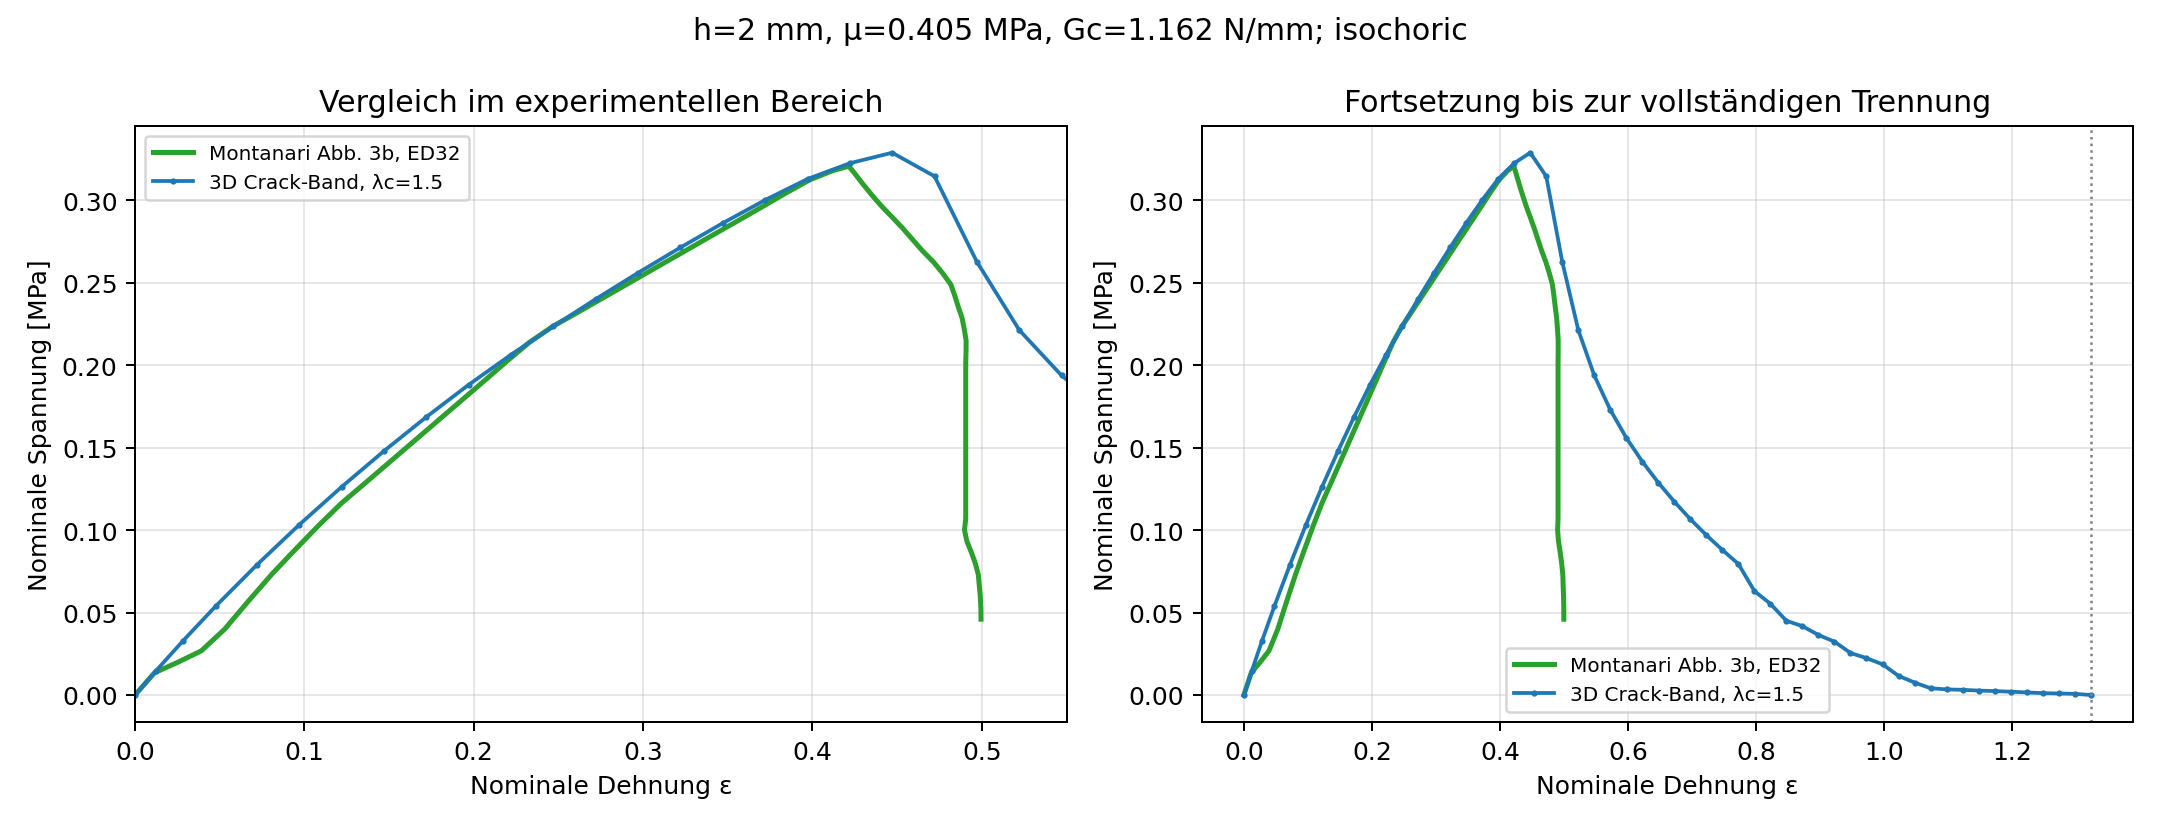

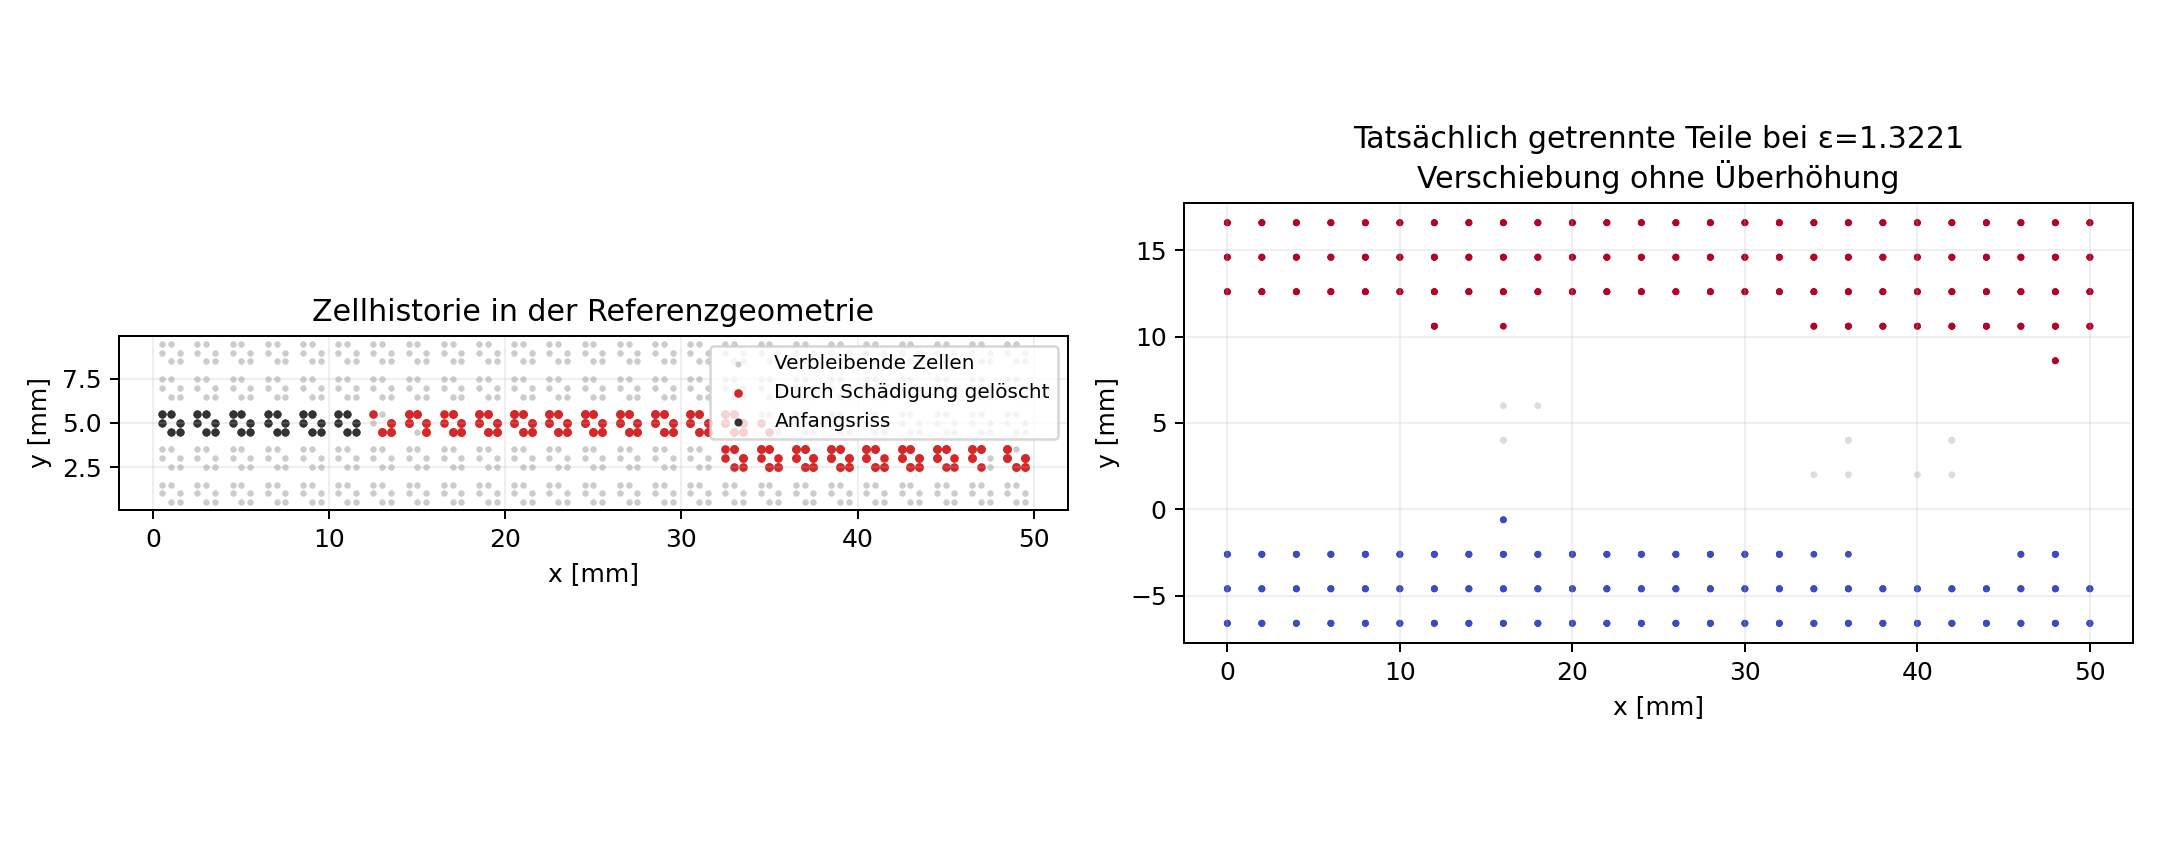

In [15]:
from IPython.display import display, Image
metrics = compare_fracture_curve(OUTDIR, PAPER_CSV)
print(json.dumps(metrics, indent=2))
metadata = dict(h_mm=params.h, lambda_c=params.lambda_c, mu_MPa=params.mu, Gc_N_per_mm=params.Gc,
                lambda_selection="Restored h=2 mm reference; lambda_c=1.5 from the earlier limited candidate study",
                reference_data="Digitized green ED32 Fig.3b data embedded in this notebook",
                comparison=metrics)
(OUTDIR/"model_comparison.json").write_text(json.dumps(metadata, indent=2))
display(Image(filename=str(make_fracture_plot(OUTDIR, PAPER_CSV))))
display(Image(filename=str(make_fracture_overview(OUTDIR, params))))


## Prüfungen und gespeicherte Felder

Die Prüfung kontrolliert den fehlenden Griff-zu-Griff-Lastpfad, die tatsächliche Endreaktion,
positives J in allen akzeptierten Zuständen, unabhängige FE-Knoten getrennter Teile, irreversible Historien, genau 50 Zeitpunkte und ein Feld je XDMF-Datei.
Alle HDF5-Verweise, Arraygrößen und Zahlenwerte werden geprüft.

In [16]:
audit = audit_fracture_run(OUTDIR, params, require_frames=50)
print(json.dumps(audit, indent=2))


{
  "separated": true,
  "separation_strain": 1.3220703124999995,
  "final_reaction_N": 5.467086055655122e-13,
  "final_J_error": 3.610124133475888e-15,
  "connected_components": 5,
  "top_bottom_common_components": 0,
  "active_cells": 1212,
  "deleted_cells": 288,
  "fields": {
    "displacement": {
      "frames": 50,
      "distinct_fields": 1
    },
    "pressure": {
      "frames": 50,
      "distinct_fields": 1
    },
    "damage": {
      "frames": 50,
      "distinct_fields": 1
    },
    "I1": {
      "frames": 50,
      "distinct_fields": 1
    },
    "failure_index": {
      "frames": 50,
      "distinct_fields": 1
    },
    "lambda_max": {
      "frames": 50,
      "distinct_fields": 1
    },
    "sigma_max": {
      "frames": 50,
      "distinct_fields": 1
    },
    "opening": {
      "frames": 50,
      "distinct_fields": 1
    },
    "nucleated": {
      "frames": 50,
      "distinct_fields": 1
    },
    "parent_cell_id": {
      "frames": 50,
      "distinct_fields"

In [17]:
import matplotlib.pyplot as plt
curve = np.atleast_1d(np.genfromtxt(OUTDIR/"load_curve.csv", delimiter=",", names=True))
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
axes[0].plot(curve["nominal_strain"], curve["deleted_cells"])
axes[0].set_ylabel("Gelöschte Zellen einschließlich Anfangsriss")
axes[1].plot(curve["nominal_strain"], curve["min_J"])
axes[1].axhline(0, color="tab:red", ls=":"); axes[1].set_ylabel("Kleinstes abgetastetes J")
axes[2].plot(curve["nominal_strain"], curve["target_fracture_dissipation_Nmm"], label="Äquivalente Öffnungsarbeit")
axes[2].plot(curve["nominal_strain"], curve["mechanical_damage_dissipation_Nmm"], label="Mechanische Schädigung")
axes[2].set_ylabel("Energie [N mm]"); axes[2].legend(fontsize=8)
for ax in axes:
    ax.set_xlabel("Nominale Dehnung ε"); ax.grid(alpha=.3)
fig.tight_layout(); fig.savefig(OUTDIR/"diagnostics.png", dpi=180); plt.show()


## Ausgabe und Weitergabe

Es genügt, `crack_band.ipynb` weiterzugeben. Der Ordner `results_crack_band/` wird beim Ausführen erzeugt.
Für die Weitergabe bereits berechneter Ergebnisse diesen Ordner mitnehmen. Alte Projektdateien sind keine Laufzeitabhängigkeit.

In ParaView `results_crack_band/displacement.xdmf` öffnen und **Warp By Vector → displacement_mm** wählen.
Die zugehörige `.h5` muss daneben liegen. Die Zeitkoordinate ist die nominale Dehnung; physikalische Zeit steht in CSV.
50 tatsächlich gerechnete positive Lastzustände werden ausgegeben, einschließlich vollständiger Trennung.

Jedes weitere Feld liegt separat vor: `pressure`, `damage`, `I1`, `failure_index`, `lambda_max`, `sigma_max`,
`opening`, `nucleated`, `parent_cell_id`, `energy_density`, `characteristic_length`, `fracture_dissipation`
(je XDMF/HDF5). Die Netze berücksichtigen die tatsächliche Elementlöschung und die unabhängigen Fragmentknoten.

`load_curve.csv`, `simulation_history.csv`, `damage_events.csv`, `step_attempts.csv` und `crackband_cell_history.csv`
dokumentieren Lastpfad und Schädigung. `checkpoints/` enthält die vollständigen MINI-Lösungen für Neustarts.
`parameters.json`, `run_summary.json`, `comparison_metrics.json`, `model_comparison.json` und `output_audit.json`
enthalten Parameter und Prüfungen. Die eingebetteten Referenzen werden ebenfalls als CSV ausgegeben.

Die resultierende Kurve wird unverändert gezeigt, auch wenn sie vom Experiment abweicht.
Quantitative Materialaussagen erfordern zusätzliche Netz- und Regularisierungsprüfungen.